In [1]:
# =========================
#  (imports + config + load data)
# =========================

import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE


import lightgbm as lgb
import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")

# ---- Reproducibility ----
SEED = 42
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False



# ---- ST004145 columns (match your CSV header; 12 features incl. DHEA) ----
hormone_columns = [
    "11-Dehydrocorticosterone_POS",
    "11-deoxycortisol_POS",
    "11-ketotestosterone_POS",
    "17a-OH-progesterone_POS",
    "Androstenedione_POS",
    "Corticosterone_POS",
    "Cortisol_POS",
    "Cortisone_POS",
    "Estradiol_POS",
    "Pregnenolone_POS",
    "Testosterone_POS",
    "DHEA-sulfate_NEG",
]

# If your notebook runs in a different working directory, you can also set:
# DATA_PATH = r"/mnt/data/ST004145_MERGED_log10_clean.csv"
DATA_PATH = "ST004145_MERGED_log10_clean.csv"


def load_st004145(path=DATA_PATH):
    df = pd.read_csv(path)

    missing = [c for c in hormone_columns if c not in df.columns]
    if missing:
        raise ValueError(f"Missing hormone columns in CSV: {missing}")

    if "Factor_Group" not in df.columns:
        raise ValueError("Missing 'Factor_Group' column in CSV.")

    X = df[hormone_columns].copy()

    # Factor_Group: control=0, case=1
    fg = df["Factor_Group"]
    if fg.dtype == object:
        fg_norm = fg.astype(str).str.strip().str.lower()
        y = fg_norm.map({"control": 0, "case": 1})
    else:
        y = fg

    if pd.isna(y).any():
        bad = df.loc[pd.isna(y), "Factor_Group"].unique()
        raise ValueError(f"Unmapped Factor_Group values: {bad}. Expected only control/case.")

    y = y.astype(int)
    return X, y


In [2]:
# =========================
#  (definitions; leak-free; 5-fold CV for all)
# =========================

class SteroidHormoneProcessor:
    """
    Leak-free preprocessing:
    - Fit ONLY on the TRAIN fold
    - Then transform VAL fold using training-fitted params
    """
    def __init__(self, scaler_kind='robust'):
        self.scaler = None
        self.selected_features = None
        self._medians = None
        self._clip_q1 = None
        self._clip_q99 = None
        self._log_cols = None
        self.scaler_kind = str(scaler_kind).lower()

    def _decide_log_cols(self, X):
        log_cols = []
        for col in X.columns:
            if X[col].min() > 0 and X[col].skew() > 1:
                log_cols.append(col)
        return log_cols

    def fit(self, X):
        Xp = X.copy().replace([np.inf, -np.inf], np.nan)

        # training medians only
        self._medians = Xp.median(numeric_only=True)
        Xp = Xp.fillna(self._medians)

        # decide log cols based on training only
        self._log_cols = self._decide_log_cols(Xp)

        # apply log for deciding clipping + scaler fit
        Xp2 = Xp.copy()
        for c in self._log_cols:
            Xp2[c] = np.log1p(Xp2[c])

        # training clipping thresholds only
        self._clip_q1, self._clip_q99 = {}, {}
        for col in Xp2.columns:
            self._clip_q1[col] = float(Xp2[col].quantile(0.01))
            self._clip_q99[col] = float(Xp2[col].quantile(0.99))

        # training scaler only
        if self.scaler_kind == 'standard':
            self.scaler = StandardScaler()
        else:
            self.scaler = RobustScaler(quantile_range=(5, 95))
        self.scaler.fit(Xp2.values)

        self.selected_features = X.columns.tolist()
        return self

    def transform(self, X):
        if self.scaler is None:
            raise RuntimeError("Processor not fitted. Call fit() on training data first.")

        Xp = X.copy().replace([np.inf, -np.inf], np.nan)
        Xp = Xp.fillna(self._medians)

        # apply the same log decision from training
        for c in self._log_cols:
            if c in Xp.columns:
                Xp[c] = np.log1p(Xp[c])

        # clip using training thresholds
        for col in Xp.columns:
            Xp[col] = Xp[col].clip(self._clip_q1[col], self._clip_q99[col])

        X_scaled = self.scaler.transform(Xp.values)
        return pd.DataFrame(X_scaled, columns=self.selected_features, index=Xp.index)

    def fit_transform(self, X):
        return self.fit(X).transform(X)


class DifficultyScorer:
    def __init__(self):
        self.centroids = None
        self.simple_model = None
        self.iso_forest = None

    def fit(self, X, y):
        Xv = X.values if isinstance(X, pd.DataFrame) else X
        yv = y.values if hasattr(y, "values") else y

        self.centroids = {}
        for cls in np.unique(yv):
            mask = yv == cls
            self.centroids[cls] = np.mean(Xv[mask], axis=0)

        self.simple_model = RandomForestClassifier(n_estimators=30, max_depth=2, random_state=SEED)
        self.simple_model.fit(Xv, yv)

        self.iso_forest = IsolationForest(contamination=0.1, random_state=SEED)
        self.iso_forest.fit(Xv)
        return self

    def score_difficulty(self, X):
        Xv = X.values if isinstance(X, pd.DataFrame) else X
        n = len(Xv)

        dist = np.zeros(n)
        conf = np.zeros(n)
        outl = np.zeros(n)

        if self.centroids:
            for i, x in enumerate(Xv):
                md = float("inf")
                for _, c in self.centroids.items():
                    md = min(md, np.linalg.norm(x - c))
                dist[i] = md
        if dist.max() > 0:
            dist = dist / dist.max()

        if self.simple_model:
            prob = self.simple_model.predict_proba(Xv)
            conf = 1 - np.max(prob, axis=1)

        if self.iso_forest:
            lab = self.iso_forest.predict(Xv)
            outl = (lab == -1).astype(float)

        return (dist + conf + outl) / 3


class CurriculumTrainer:
    def __init__(self, model, curriculum_stages=3, stage_epochs=None):
        self.model = model
        self.curriculum_stages = curriculum_stages
        self.stage_epochs = stage_epochs
        self.difficulty_scorer = DifficultyScorer()
        self.difficulty_scores = None

    def _subset(self, X, y, stage):
        n = len(X)
        frac = 0.3 + 0.7 * (stage / (self.curriculum_stages - 1))
        m = max(1, int(n * frac))

        idx = np.argsort(self.difficulty_scores)[:m]
        Xs = X.iloc[idx] if isinstance(X, pd.DataFrame) else X[idx]
        ys = y.iloc[idx] if isinstance(y, pd.Series) else y[idx]
        return Xs, ys

    def fit_with_curriculum(self, X, y, verbose=False):
        self.difficulty_scorer.fit(X, y)
        self.difficulty_scores = self.difficulty_scorer.score_difficulty(X)

        if self.stage_epochs is None:
            total_epochs = min(100, max(20, len(X) // 10))
            self.stage_epochs = max(1, total_epochs // self.curriculum_stages)

        for stage in range(self.curriculum_stages):
            Xs, ys = self._subset(X, y, stage)

            if hasattr(self.model, "partial_fit"):
                classes = np.unique(y)
                for _ in range(self.stage_epochs):
                    self.model.partial_fit(Xs, ys, classes=classes)
            else:
                if hasattr(self.model, "warm_start") and hasattr(self.model, "n_estimators"):
                    if stage == 0:
                        self.model.fit(Xs, ys)
                    else:
                        cur = self.model.n_estimators
                        self.model.set_params(n_estimators=cur + self.stage_epochs)
                        self.model.fit(Xs, ys)
                else:
                    self.model.fit(Xs, ys)

        return self.model



# ============================================
# OOF utilities
# ============================================

def save_oof_outputs(model_name, y_true, y_prob, out_dir="oof_outputs", threshold=0.5):
    """
    Save out-of-fold predictions for downstream ROC, confusion matrix,
    and metric-table generation.
    """
    import os
    from sklearn.metrics import (
        roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
    )

    os.makedirs(out_dir, exist_ok=True)

    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    np.save(os.path.join(out_dir, f"{model_name}_y_true.npy"), y_true)
    np.save(os.path.join(out_dir, f"{model_name}_y_prob.npy"), y_prob)
    np.save(os.path.join(out_dir, f"{model_name}_y_pred.npy"), y_pred)

    oof_df = pd.DataFrame({
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred,
    })
    oof_df.to_csv(os.path.join(out_dir, f"{model_name}_oof_predictions.csv"), index=False)

    metrics = {
        "Model": model_name,
        "AUC": float(roc_auc_score(y_true, y_prob)),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
    }
    pd.DataFrame([metrics]).to_csv(
        os.path.join(out_dir, f"{model_name}_metrics.csv"),
        index=False
    )

    return metrics



def train_baselines_cv(
    X, y,
    use_curriculum=True,
    curriculum_stages=3,
    n_splits=5,
    sampling=None,
    save_oof_for=None,
    out_dir="oof_outputs"
):
    """
    Leak-free 5-fold CV: processor.fit_transform on TRAIN fold only.
    Optionally save out-of-fold predictions for selected baseline models.
    """
    print(f"\n Baselines (Curriculum: {use_curriculum}) | {n_splits}-fold CV")

    if save_oof_for is None:
        save_oof_for = []

    models = {
        "LightGBM": lgb.LGBMClassifier(
            n_estimators=100, max_depth=3, learning_rate=0.03,
            random_state=SEED, verbosity=-1, warm_start=True
        ),
        "LR": LogisticRegression(C=0.1, max_iter=1000, random_state=SEED),
        "SVM": SVC(kernel="rbf", probability=True, random_state=SEED),
    }

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    out = {}

    for name, model in models.items():
        scores = []
        oof_y_true = []
        oof_y_prob = []

        for tr, va in skf.split(X, y):
            Xtr_raw, Xva_raw = X.iloc[tr], X.iloc[va]
            ytr, yva = y.iloc[tr], y.iloc[va]

            # sampling (TRAIN fold only) to avoid leakage
            Xtr_raw_s, ytr_s = apply_sampling_train_fold_df(
                Xtr_raw, ytr, sampling=sampling, random_state=SEED
            )

            processor = SteroidHormoneProcessor()
            Xtr = processor.fit_transform(Xtr_raw_s)
            Xva = processor.transform(Xva_raw)

            if use_curriculum:
                trainer = CurriculumTrainer(
                    model.__class__(**model.get_params()),
                    curriculum_stages=curriculum_stages
                )
                clf = trainer.fit_with_curriculum(Xtr, ytr_s, verbose=False)
            else:
                clf = model.__class__(**model.get_params())
                clf.fit(Xtr, ytr_s)

            p = clf.predict_proba(Xva)[:, 1]
            scores.append(roc_auc_score(yva, p))

            full_model_name = f"Baseline_{name}_{'Curriculum' if use_curriculum else 'Standard'}"
            if full_model_name in save_oof_for:
                oof_y_true.extend(np.asarray(yva).astype(int).tolist())
                oof_y_prob.extend(np.asarray(p).astype(float).tolist())

        out[name] = {"mean_auc": float(np.mean(scores)), "std_auc": float(np.std(scores))}
        tag = "curriculum" if use_curriculum else "standard"
        print(f"    {name} ({tag}): {out[name]['mean_auc']:.4f} ± {out[name]['std_auc']:.4f}")

        full_model_name = f"Baseline_{name}_{'Curriculum' if use_curriculum else 'Standard'}"
        if full_model_name in save_oof_for and len(oof_y_true) > 0:
            metrics = save_oof_outputs(
                model_name=full_model_name,
                y_true=np.array(oof_y_true),
                y_prob=np.array(oof_y_prob),
                out_dir=out_dir
            )
            out[name]["oof_auc"] = metrics["AUC"]
            out[name]["oof_accuracy"] = metrics["Accuracy"]
            out[name]["oof_precision"] = metrics["Precision"]
            out[name]["oof_recall"] = metrics["Recall"]
            out[name]["oof_f1"] = metrics["F1"]

    return out


# =========================
#  Sampling helpers (SMOTE / simple cGAN) - TRAIN FOLD ONLY
#  Strictly avoid leakage: fit/generate ONLY on Xtr within each CV fold.
# =========================

def _safe_smote_df(Xtr_df, ytr, random_state=SEED):
    y_arr = np.asarray(ytr)
    n_min = int((y_arr == 1).sum())
    n_maj = int((y_arr == 0).sum())
    if n_min == 0 or n_maj == 0:
        return Xtr_df, ytr

    k = max(1, min(5, n_min - 1))
    if k <= 0:
        return Xtr_df, ytr

    sm = SMOTE(random_state=random_state, k_neighbors=k)
    X_res, y_res = sm.fit_resample(Xtr_df.values, y_arr)
    X_res = pd.DataFrame(X_res, columns=Xtr_df.columns)
    y_res = pd.Series(y_res)
    return X_res, y_res


class _TabularCGAN(nn.Module):
    def __init__(self, x_dim, z_dim=16, hidden=64):
        super().__init__()
        self.z_dim = z_dim
        self.gen = nn.Sequential(
            nn.Linear(z_dim + 1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, x_dim),
        )
        self.disc = nn.Sequential(
            nn.Linear(x_dim + 1, hidden),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden, 1),
            nn.Sigmoid(),
        )

    def g(self, z, y):
        return self.gen(torch.cat([z, y], dim=1))

    def d(self, x, y):
        return self.disc(torch.cat([x, y], dim=1))


def _cgan_augment_minority_df(
    Xtr_df, ytr,
    random_state=SEED,
    epochs=250,
    batch_size=32,
    z_dim=16,
    target_ratio=1.0,
    lr_g=2e-4,
    lr_d=2e-4,
):
    rng = np.random.RandomState(random_state)
    X = np.asarray(Xtr_df.values, dtype=np.float32)
    y = np.asarray(ytr, dtype=np.int64)

    n_min = int((y == 1).sum())
    n_maj = int((y == 0).sum())
    if n_min == 0 or n_maj == 0 or n_min >= n_maj:
        return Xtr_df, pd.Series(y)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    gan = _TabularCGAN(x_dim=X.shape[1], z_dim=z_dim).to(device)

    X_t = torch.tensor(X, device=device)
    y_t = torch.tensor(y.reshape(-1, 1).astype(np.float32), device=device)

    opt_g = optim.Adam(gan.gen.parameters(), lr=float(lr_g))
    opt_d = optim.Adam(gan.disc.parameters(), lr=float(lr_d))
    bce = nn.BCELoss()

    idx = np.arange(len(X))
    for _ in range(epochs):
        rng.shuffle(idx)
        for s in range(0, len(X), batch_size):
            b = idx[s:s + batch_size]
            xb = X_t[b]
            yb = y_t[b]

            # D
            z = torch.randn(len(b), z_dim, device=device)
            fake = gan.g(z, yb).detach()
            real_pred = gan.d(xb, yb)
            fake_pred = gan.d(fake, yb)
            d_loss = (bce(real_pred, torch.ones_like(real_pred)) +
                      bce(fake_pred, torch.zeros_like(fake_pred))) / 2
            opt_d.zero_grad()
            d_loss.backward()
            opt_d.step()

            # G
            z = torch.randn(len(b), z_dim, device=device)
            gen = gan.g(z, yb)
            pred = gan.d(gen, yb)
            g_loss = bce(pred, torch.ones_like(pred))
            opt_g.zero_grad()
            g_loss.backward()
            opt_g.step()

    target_ratio = float(target_ratio)
    if target_ratio <= 0:
        return Xtr_df, pd.Series(y)

    target_min = int(np.ceil(target_ratio * n_maj))
    need = max(0, target_min - n_min)
    if need == 0:
        return Xtr_df, pd.Series(y)
    y_gen = np.ones((need, 1), dtype=np.float32)
    z = torch.randn(need, z_dim, device=device)
    with torch.no_grad():
        x_syn = gan.g(z, torch.tensor(y_gen, device=device)).cpu().numpy()

    X_aug = np.vstack([X, x_syn])
    y_aug = np.concatenate([y, np.ones(need, dtype=np.int64)])

    X_aug = pd.DataFrame(X_aug, columns=Xtr_df.columns)
    y_aug = pd.Series(y_aug)
    return X_aug, y_aug


def apply_sampling_train_fold_df(Xtr_df, ytr, sampling=None, random_state=SEED, sampling_params=None):
    if sampling is None:
        return Xtr_df, ytr
    s = str(sampling).strip().lower()
    if s == "smote":
        return _safe_smote_df(Xtr_df, ytr, random_state=random_state)
    if s == "gan":
        p = sampling_params or {}
        return _cgan_augment_minority_df(
            Xtr_df, ytr,
            random_state=random_state,
            epochs=p.get('gan_epochs', 250),
            batch_size=p.get('gan_batch_size', 32),
            z_dim=p.get('gan_z_dim', 16),
            target_ratio=p.get('gan_target_ratio', 1.0),
            lr_g=p.get('gan_lr_g', 2e-4),
            lr_d=p.get('gan_lr_d', 2e-4),
        )
    raise ValueError(f"Unknown sampling method: {sampling}")

# --------------------------
# Transformer + LGB Hybrid
# --------------------------

class HormonePathwayTransformer(nn.Module):
    def __init__(self, input_dim=12, embedding_dim=8, num_heads=2, num_layers=1, dropout=0.3):
        super().__init__()
        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, embedding_dim),
            nn.BatchNorm1d(embedding_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.pos_encoder = nn.Parameter(torch.randn(1, 1, embedding_dim) * 0.01)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dim_feedforward=embedding_dim * 2,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers, enable_nested_tensor=False)

        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim),
            nn.BatchNorm1d(embedding_dim),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(embedding_dim, 2)
        )

    def forward(self, x):
        x = self.input_projection(x)
        x = x.unsqueeze(1) + self.pos_encoder
        x = self.transformer(x).squeeze(1)
        emb = x
        logits = self.classifier(x)
        return emb, logits

    def encode(self, x):
        self.eval()
        with torch.no_grad():
            x = self.input_projection(x)
            x = x.unsqueeze(1) + self.pos_encoder
            x = self.transformer(x).squeeze(1)
        return x.cpu().numpy()


class TransformerCurriculumTrainer:
    """
    IMPORTANT: works on *already preprocessed* data for that fold (no internal fit_transform).
    """
    def __init__(self, transformer, curriculum_stages=3, device=None):
        self.transformer = transformer
        self.curriculum_stages = curriculum_stages
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.difficulty_scorer = DifficultyScorer()

    def train_on_preprocessed(self, X_proc_df, y, epochs=30, batch_size=8, lr=0.0005):
        Xp = X_proc_df
        self.difficulty_scorer.fit(Xp, y)
        diff = self.difficulty_scorer.score_difficulty(Xp)
        sorted_idx = np.argsort(diff)

        X_tensor = torch.FloatTensor(Xp.values).to(self.device)
        y_tensor = torch.LongTensor(y.values).to(self.device)

        optimizer = optim.AdamW(self.transformer.parameters(), lr=lr, weight_decay=0.1)
        criterion = nn.CrossEntropyLoss()

        epochs_per_stage = max(1, epochs // self.curriculum_stages)

        for stage in range(self.curriculum_stages):
            frac = 0.3 + 0.7 * (stage / (self.curriculum_stages - 1))
            n = max(1, int(len(sorted_idx) * frac))
            stage_idx = sorted_idx[:n]

            ds = TensorDataset(X_tensor[stage_idx], y_tensor[stage_idx])
            dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

            for _ in range(epochs_per_stage):
                self.transformer.train()
                for bx, by in dl:
                    optimizer.zero_grad()
                    _, logits = self.transformer(bx)
                    loss = criterion(logits, by)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.transformer.parameters(), 0.5)
                    optimizer.step()

        return self.transformer


class SteroidHormoneHybridTransformerLGB:
    """
    Each fold has its own processor fitted on TRAIN only; used consistently.
    """
    def __init__(self, use_curriculum=True, curriculum_stages=3, device=None):
        self.use_curriculum = use_curriculum
        self.curriculum_stages = curriculum_stages
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        pp = processor_params or {}
        self.processor = SteroidHormoneProcessor(**pp)
        self.transformer = HormonePathwayTransformer(input_dim=12).to(self.device)
        self.lgb_model = None

    def fit(self, X_train_raw, y_train):
        X_train_proc = self.processor.fit_transform(X_train_raw)

        if self.use_curriculum:
            trainer = TransformerCurriculumTrainer(
                self.transformer, curriculum_stages=self.curriculum_stages, device=self.device
            )
            trainer.train_on_preprocessed(
                X_train_proc, y_train, epochs=30, batch_size=min(8, max(2, len(X_train_proc)//2))
            )
        else:
            Xt = torch.FloatTensor(X_train_proc.values).to(self.device)
            yt = torch.LongTensor(y_train.values).to(self.device)
            ds = TensorDataset(Xt, yt)
            dl = DataLoader(ds, batch_size=min(8, max(2, len(X_train_proc)//2)), shuffle=True, drop_last=True)

            optimizer = optim.AdamW(self.transformer.parameters(), lr=0.0005, weight_decay=0.1)
            criterion = nn.CrossEntropyLoss()

            for _ in range(30):
                self.transformer.train()
                for bx, by in dl:
                    optimizer.zero_grad()
                    _, logits = self.transformer(bx)
                    loss = criterion(logits, by)
                    loss.backward()
                    optimizer.step()

        # train LGB on train embeddings
        emb_train = self.extract_embeddings(X_train_raw)
        self.lgb_model = lgb.LGBMClassifier(
            n_estimators=100, max_depth=3, learning_rate=0.03,
            random_state=SEED, verbosity=-1
        )
        self.lgb_model.fit(emb_train, y_train)
        return self

    def extract_embeddings(self, X_raw):
        X_proc = self.processor.transform(X_raw)
        Xt = torch.FloatTensor(X_proc.values).to(self.device)
        emb = self.transformer.encode(Xt)
        cols = [f"embedding_{i}" for i in range(emb.shape[1])]
        return pd.DataFrame(emb, columns=cols, index=X_raw.index)

    def predict_proba(self, X_raw):
        emb = self.extract_embeddings(X_raw)
        return self.lgb_model.predict_proba(emb)



# =========================
#  HYBRID variants (Transformer + different heads)
# =========================

def _fit_processor_and_transformer(processor, transformer, X_train_raw, y_train,
                                  use_curriculum=True, curriculum_stages=3, device=None,
                                  epochs=30, batch_size_cap=8, lr=0.0005):
    """
    Leak-free: processor.fit + transformer training are done ONLY on TRAIN fold.
    Returns: X_train_proc (DataFrame)
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    X_train_proc = processor.fit_transform(X_train_raw)

    if use_curriculum:
        trainer = TransformerCurriculumTrainer(
            transformer, curriculum_stages=curriculum_stages, device=device
        )
        trainer.train_on_preprocessed(
            X_train_proc, y_train,
            epochs=epochs,
            batch_size=min(batch_size_cap, max(2, len(X_train_proc)//2)),
            lr=lr
        )
    else:
        Xt = torch.FloatTensor(X_train_proc.values).to(device)
        yt = torch.LongTensor(y_train.values).to(device)
        ds = TensorDataset(Xt, yt)
        dl = DataLoader(ds, batch_size=min(batch_size_cap, max(2, len(X_train_proc)//2)),
                        shuffle=True, drop_last=True)

        optimizer = optim.AdamW(transformer.parameters(), lr=lr, weight_decay=0.1)
        criterion = nn.CrossEntropyLoss()

        for _ in range(epochs):
            transformer.train()
            for bx, by in dl:
                optimizer.zero_grad()
                _, logits = transformer(bx)
                loss = criterion(logits, by)
                loss.backward()
                optimizer.step()

    return X_train_proc


def _transformer_proba_on_processed(transformer, X_proc_df, device=None):
    """
    Get P(class=1) from transformer classifier head, given preprocessed fold data.
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    transformer.eval()
    with torch.no_grad():
        Xt = torch.FloatTensor(X_proc_df.values).to(device)
        _, logits = transformer(Xt)
        probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
    return probs


class SteroidHormoneHybridTransformerLRHead:
    """
    Transformer -> Embedding -> LogisticRegression(head)
    """
    def __init__(self, use_curriculum=True, curriculum_stages=3, device=None):
        self.use_curriculum = use_curriculum
        self.curriculum_stages = curriculum_stages
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        pp = processor_params or {}
        self.processor = SteroidHormoneProcessor(**pp)
        self.transformer = HormonePathwayTransformer(input_dim=12).to(self.device)
        default_lr = dict(max_iter=5000, solver='liblinear', class_weight='balanced', random_state=SEED)
        if lr_params:
            default_lr.update(lr_params)
        # Ensure reproducibility
        default_lr['random_state'] = SEED
        self.lr_model = LogisticRegression(**default_lr)

    def fit(self, X_train_raw, y_train):
        _fit_processor_and_transformer(
            self.processor, self.transformer, X_train_raw, y_train,
            use_curriculum=self.use_curriculum,
            curriculum_stages=self.curriculum_stages,
            device=self.device
        )
        emb_train = self.extract_embeddings(X_train_raw)
        self.lr_model.fit(emb_train, y_train)
        return self

    def extract_embeddings(self, X_raw):
        X_proc = self.processor.transform(X_raw)
        Xt = torch.FloatTensor(X_proc.values).to(self.device)
        emb = self.transformer.encode(Xt)
        cols = [f"embedding_{i}" for i in range(emb.shape[1])]
        return pd.DataFrame(emb, columns=cols, index=X_raw.index)

    def predict_proba(self, X_raw):
        emb = self.extract_embeddings(X_raw)
        return self.lr_model.predict_proba(emb)


class SteroidHormoneHybridTransformerLinearSVMHead:
    """
    Transformer -> Embedding -> Linear SVM(head) with probability=True
    """
    def __init__(self, use_curriculum=True, curriculum_stages=3, device=None):
        self.use_curriculum = use_curriculum
        self.curriculum_stages = curriculum_stages
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        pp = processor_params or {}
        self.processor = SteroidHormoneProcessor(**pp)
        self.transformer = HormonePathwayTransformer(input_dim=12).to(self.device)
        self.svm_model = SVC(
            kernel="linear", probability=True, class_weight="balanced", random_state=SEED
        )

    def fit(self, X_train_raw, y_train):
        _fit_processor_and_transformer(
            self.processor, self.transformer, X_train_raw, y_train,
            use_curriculum=self.use_curriculum,
            curriculum_stages=self.curriculum_stages,
            device=self.device
        )
        emb_train = self.extract_embeddings(X_train_raw)
        self.svm_model.fit(emb_train, y_train)
        return self

    def extract_embeddings(self, X_raw):
        X_proc = self.processor.transform(X_raw)
        Xt = torch.FloatTensor(X_proc.values).to(self.device)
        emb = self.transformer.encode(Xt)
        cols = [f"embedding_{i}" for i in range(emb.shape[1])]
        return pd.DataFrame(emb, columns=cols, index=X_raw.index)

    def predict_proba(self, X_raw):
        emb = self.extract_embeddings(X_raw)
        return self.svm_model.predict_proba(emb)


class SteroidHormoneHybridTransformerXGBHead:
    """
    Transformer -> Embedding -> XGBoost(head)
    """
    def __init__(self, use_curriculum=True, curriculum_stages=3, device=None):
        self.use_curriculum = use_curriculum
        self.curriculum_stages = curriculum_stages
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        pp = processor_params or {}
        self.processor = SteroidHormoneProcessor(**pp)
        self.transformer = HormonePathwayTransformer(input_dim=12).to(self.device)
        self.xgb_model = xgb.XGBClassifier(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            reg_alpha=0.0,
            objective="binary:logistic",
            eval_metric="auc",
            random_state=SEED,
            n_jobs=1
        )

    def fit(self, X_train_raw, y_train):
        _fit_processor_and_transformer(
            self.processor, self.transformer, X_train_raw, y_train,
            use_curriculum=self.use_curriculum,
            curriculum_stages=self.curriculum_stages,
            device=self.device
        )
        emb_train = self.extract_embeddings(X_train_raw)
        self.xgb_model.fit(emb_train, y_train)
        return self

    def extract_embeddings(self, X_raw):
        X_proc = self.processor.transform(X_raw)
        Xt = torch.FloatTensor(X_proc.values).to(self.device)
        emb = self.transformer.encode(Xt)
        cols = [f"embedding_{i}" for i in range(emb.shape[1])]
        return pd.DataFrame(emb, columns=cols, index=X_raw.index)

    def predict_proba(self, X_raw):
        emb = self.extract_embeddings(X_raw)
        # XGB returns shape (n, ) for predict_proba? Actually (n,2)
        return self.xgb_model.predict_proba(emb)


class SteroidHormoneHybridConcatLR:
    """
    (Processed raw features) + (Transformer embedding) -> LogisticRegression(head)
    """
    def __init__(self, use_curriculum=True, curriculum_stages=3, device=None, lr_params=None, processor_params=None):
        self.use_curriculum = use_curriculum
        self.curriculum_stages = curriculum_stages
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        pp = processor_params or {}
        self.processor = SteroidHormoneProcessor(**pp)
        self.transformer = HormonePathwayTransformer(input_dim=12).to(self.device)
        self.lr_model = LogisticRegression(
            max_iter=5000, solver="liblinear", class_weight="balanced", random_state=SEED
        )

    def fit(self, X_train_raw, y_train):
        _fit_processor_and_transformer(
            self.processor, self.transformer, X_train_raw, y_train,
            use_curriculum=self.use_curriculum,
            curriculum_stages=self.curriculum_stages,
            device=self.device
        )
        Xtr_proc = self.processor.transform(X_train_raw)
        emb_train = self._emb_df_from_proc(Xtr_proc, X_train_raw.index)
        feats = pd.concat([Xtr_proc.reset_index(drop=True), emb_train.reset_index(drop=True)], axis=1)
        self.lr_model.fit(feats, y_train.reset_index(drop=True))
        return self

    def _emb_df_from_proc(self, X_proc_df, index):
        Xt = torch.FloatTensor(X_proc_df.values).to(self.device)
        emb = self.transformer.encode(Xt)
        cols = [f"embedding_{i}" for i in range(emb.shape[1])]
        return pd.DataFrame(emb, columns=cols, index=index)

    def predict_proba(self, X_raw):
        Xp = self.processor.transform(X_raw)
        emb = self._emb_df_from_proc(Xp, X_raw.index)
        feats = pd.concat([Xp.reset_index(drop=True), emb.reset_index(drop=True)], axis=1)
        return self.lr_model.predict_proba(feats)


class SteroidHormoneHybridStackLR:
    """
    Stack: (Transformer predicted prob) + (Processed raw features) -> LogisticRegression(head)
    """
    def __init__(self, use_curriculum=True, curriculum_stages=3, device=None):
        self.use_curriculum = use_curriculum
        self.curriculum_stages = curriculum_stages
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        pp = processor_params or {}
        self.processor = SteroidHormoneProcessor(**pp)
        self.transformer = HormonePathwayTransformer(input_dim=12).to(self.device)
        self.lr_model = LogisticRegression(
            max_iter=5000, solver="liblinear", class_weight="balanced", random_state=SEED
        )

    def fit(self, X_train_raw, y_train):
        Xtr_proc = _fit_processor_and_transformer(
            self.processor, self.transformer, X_train_raw, y_train,
            use_curriculum=self.use_curriculum,
            curriculum_stages=self.curriculum_stages,
            device=self.device
        )
        tprob = _transformer_proba_on_processed(self.transformer, Xtr_proc, device=self.device)
        feats = Xtr_proc.copy()
        feats["transformer_p1"] = tprob
        self.lr_model.fit(feats, y_train)
        return self

    def predict_proba(self, X_raw):
        Xp = self.processor.transform(X_raw)
        tprob = _transformer_proba_on_processed(self.transformer, Xp, device=self.device)
        feats = Xp.copy()
        feats["transformer_p1"] = tprob
        return self.lr_model.predict_proba(feats)



def _cv_driver(
    X, y,
    model_ctor,
    label,
    n_splits=5,
    sampling=None,
    sampling_params=None,
    save_oof=False,
    oof_model_name=None,
    out_dir="oof_outputs"
):
    print(f"\n {label} | {n_splits}-fold CV")
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    scores = []
    oof_y_true = []
    oof_y_prob = []

    for tr, va in skf.split(X, y):
        Xtr_raw, Xva_raw = X.iloc[tr], X.iloc[va]
        ytr, yva = y.iloc[tr], y.iloc[va]

        # sampling (TRAIN fold only) to avoid leakage
        Xtr_raw_s, ytr_s = apply_sampling_train_fold_df(
            Xtr_raw, ytr, sampling=sampling, random_state=SEED, sampling_params=sampling_params
        )

        m = model_ctor()
        m.fit(Xtr_raw_s, ytr_s)
        p = m.predict_proba(Xva_raw)[:, 1]
        scores.append(roc_auc_score(yva, p))

        if save_oof:
            oof_y_true.extend(np.asarray(yva).astype(int).tolist())
            oof_y_prob.extend(np.asarray(p).astype(float).tolist())

    mean_auc = float(np.mean(scores))
    std_auc = float(np.std(scores))
    print(f"    {label}: {mean_auc:.4f} ± {std_auc:.4f}")

    result = {"mean_auc": mean_auc, "std_auc": std_auc}

    if save_oof and len(oof_y_true) > 0:
        model_name = oof_model_name if oof_model_name is not None else label.replace(" ", "_")
        metrics = save_oof_outputs(
            model_name=model_name,
            y_true=np.array(oof_y_true),
            y_prob=np.array(oof_y_prob),
            out_dir=out_dir
        )
        result["oof_auc"] = metrics["AUC"]
        result["oof_accuracy"] = metrics["Accuracy"]
        result["oof_precision"] = metrics["Precision"]
        result["oof_recall"] = metrics["Recall"]
        result["oof_f1"] = metrics["F1"]

    return result


def hybrid_transformer_lr_cv(X, y, use_curriculum=True, curriculum_stages=3, n_splits=5, sampling=None):
    tag = "curriculum" if use_curriculum else "standard"
    label = f"Hybrid_Transformer+LR(head) ({tag})"
    return _cv_driver(
        X, y,
        model_ctor=lambda: SteroidHormoneHybridTransformerLRHead(
            use_curriculum=use_curriculum, curriculum_stages=curriculum_stages
        ),
        label=label,
        n_splits=n_splits,
        sampling=sampling,
        sampling_params=sampling_params
    )


def hybrid_transformer_linsvm_cv(X, y, use_curriculum=True, curriculum_stages=3, n_splits=5, sampling=None):
    tag = "curriculum" if use_curriculum else "standard"
    label = f"Hybrid_Transformer+LinearSVM(head) ({tag})"
    return _cv_driver(
        X, y,
        model_ctor=lambda: SteroidHormoneHybridTransformerLinearSVMHead(
            use_curriculum=use_curriculum, curriculum_stages=curriculum_stages
        ),
        label=label,
        n_splits=n_splits,
        sampling=sampling,
        sampling_params=sampling_params
    )


def hybrid_transformer_xgb_cv(X, y, use_curriculum=True, curriculum_stages=3, n_splits=5, sampling=None):
    tag = "curriculum" if use_curriculum else "standard"
    label = f"Hybrid_Transformer+XGB(head) ({tag})"
    return _cv_driver(
        X, y,
        model_ctor=lambda: SteroidHormoneHybridTransformerXGBHead(
            use_curriculum=use_curriculum, curriculum_stages=curriculum_stages
        ),
        label=label,
        n_splits=n_splits,
        sampling=sampling,
        sampling_params=sampling_params
    )



def hybrid_concat_lr_cv(
    X, y,
    use_curriculum=True,
    curriculum_stages=3,
    n_splits=5,
    sampling=None,
    lr_params=None,
    processor_params=None,
    sampling_params=None,
    save_oof=False,
    oof_model_name=None,
    out_dir="oof_outputs"
):
    tag = "curriculum" if use_curriculum else "standard"
    label = f"Hybrid_concat_LR ({tag})"
    return _cv_driver(
        X, y,
        model_ctor=lambda: SteroidHormoneHybridConcatLR(
            use_curriculum=use_curriculum,
            curriculum_stages=curriculum_stages,
            lr_params=lr_params,
            processor_params=processor_params,
        ),
        label=label,
        n_splits=n_splits,
        sampling=sampling,
        sampling_params=sampling_params,
        save_oof=save_oof,
        oof_model_name=oof_model_name,
        out_dir=out_dir
    )


def hybrid_stack_lr_cv(X, y, use_curriculum=True, curriculum_stages=3, n_splits=5, sampling=None):
    tag = "curriculum" if use_curriculum else "standard"
    label = f"Hybrid_stack_LR ({tag})"
    return _cv_driver(
        X, y,
        model_ctor=lambda: SteroidHormoneHybridStackLR(
            use_curriculum=use_curriculum, curriculum_stages=curriculum_stages
        ),
        label=label,
        n_splits=n_splits,
        sampling=sampling,
        sampling_params=sampling_params
    )


def hybrid_lgb_cv(X, y, use_curriculum=True, curriculum_stages=3, n_splits=5, sampling=None):
    print(f"\n Hybrid_Transformer+LGB(head) (Curriculum: {use_curriculum}) | {n_splits}-fold CV")
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    scores = []
    for tr, va in skf.split(X, y):
        Xtr_raw, Xva_raw = X.iloc[tr], X.iloc[va]
        ytr, yva = y.iloc[tr], y.iloc[va]
        # sampling (TRAIN fold only) to avoid leakage
        Xtr_raw_s, ytr_s = apply_sampling_train_fold_df(Xtr_raw, ytr, sampling=sampling, random_state=SEED)

        # sampling (TRAIN fold only) to avoid leakage
        Xtr_raw_s, ytr_s = apply_sampling_train_fold_df(Xtr_raw, ytr, sampling=sampling, random_state=SEED)

        m = SteroidHormoneHybridTransformerLGB(use_curriculum=use_curriculum, curriculum_stages=curriculum_stages)
        m.fit(Xtr_raw_s, ytr_s)

        p = m.predict_proba(Xva_raw)[:, 1]
        scores.append(roc_auc_score(yva, p))

    mean_auc = float(np.mean(scores))
    std_auc = float(np.std(scores))
    tag = "curriculum" if use_curriculum else "standard"
    print(f"    Hybrid_Transformer+LGB(head) ({tag}): {mean_auc:.4f} ± {std_auc:.4f}")
    return {"mean_auc": mean_auc, "std_auc": std_auc}



def comprehensive_comparison(X, y, n_splits=5, save_oof_for=None, out_dir="oof_outputs"):
    print("\n" + "="*80)
    print(f" COMPREHENSIVE COMPARISON (Leak-free) | {n_splits}-fold CV")
    print("="*80)

    if save_oof_for is None:
        save_oof_for = []

    results = {}

    # ------------------------------------------------
    # Hybrids: Hybrid_concat_LR (5 combos only)
    # 1) Standard + GAN
    # 2) Standard + Smote
    # 3) Curriculum (no sampling)
    # 4) Curriculum + GAN
    # 5) Curriculum + Smote
    # ------------------------------------------------
    print("\n" + "-"*40)
    print("HYBRID_CONCAT_LR - SELECTED 5 COMBOS")
    print("-"*40)

    results["Hybrid_concat_LR_Standard_GAN"] = hybrid_concat_lr_cv(
        X, y, use_curriculum=False, n_splits=n_splits, sampling="gan",
        save_oof=("Hybrid_concat_LR_Standard_GAN" in save_oof_for),
        oof_model_name="Hybrid_concat_LR_Standard_GAN",
        out_dir=out_dir
    )
    results["Hybrid_concat_LR_Standard_Smote"] = hybrid_concat_lr_cv(
        X, y, use_curriculum=False, n_splits=n_splits, sampling="smote",
        save_oof=("Hybrid_concat_LR_Standard_Smote" in save_oof_for),
        oof_model_name="Hybrid_concat_LR_Standard_Smote",
        out_dir=out_dir
    )
    results["Hybrid_concat_LR_Curriculum"] = hybrid_concat_lr_cv(
        X, y, use_curriculum=True, n_splits=n_splits, sampling=None,
        save_oof=("Hybrid_concat_LR_Curriculum" in save_oof_for),
        oof_model_name="Hybrid_concat_LR_Curriculum",
        out_dir=out_dir
    )
    results["Hybrid_concat_LR_Curriculum_GAN"] = hybrid_concat_lr_cv(
        X, y, use_curriculum=True, n_splits=n_splits, sampling="gan",
        save_oof=("Hybrid_concat_LR_Curriculum_GAN" in save_oof_for),
        oof_model_name="Hybrid_concat_LR_Curriculum_GAN",
        out_dir=out_dir
    )
    results["Hybrid_concat_LR_Curriculum_Smote"] = hybrid_concat_lr_cv(
        X, y, use_curriculum=True, n_splits=n_splits, sampling="smote",
        save_oof=("Hybrid_concat_LR_Curriculum_Smote" in save_oof_for),
        oof_model_name="Hybrid_concat_LR_Curriculum_Smote",
        out_dir=out_dir
    )

    # ------------------------------------------------
    # Baselines: Standard only (selected)
    # 6) Baseline_LR_Standard
    # 7) Baseline_SVM_Standard
    # 8) Baseline_LightGBM_Standard
    # ------------------------------------------------
    print("\n" + "-"*40)
    print("BASELINES - STANDARD (SELECTED)")
    print("-"*40)

    b_std = train_baselines_cv(
        X, y,
        use_curriculum=False,
        n_splits=n_splits,
        sampling=None,
        save_oof_for=save_oof_for,
        out_dir=out_dir
    )
    for k in ["LR", "SVM", "LightGBM"]:
        results[f"Baseline_{k}_Standard"] = b_std[k]

    rows = []
    for name, m in results.items():
        row = {
            "Model": name,
            "AUC-ROC": f"{m['mean_auc']:.4f} ± {m['std_auc']:.4f}",
            "mean_auc": m["mean_auc"],
            "std_auc": m["std_auc"],
        }
        if "oof_auc" in m:
            row["oof_auc"] = m["oof_auc"]
            row["oof_accuracy"] = m["oof_accuracy"]
            row["oof_precision"] = m["oof_precision"]
            row["oof_recall"] = m["oof_recall"]
            row["oof_f1"] = m["oof_f1"]
        rows.append(row)

    out = pd.DataFrame(rows).sort_values("mean_auc", ascending=False)
    out.to_csv("curriculum_comparison_selected_models.csv", index=False)
    print("\n Saved: curriculum_comparison_selected_models.csv")
    return out, results


In [3]:
# --- Resumable tuning (append to CSV + resume after interruption) ---
import os
import time
import json

def _cfg_key_from_cfg(cfg):
    """Create a stable unique key for each config (used for resume)."""
    lr = cfg.get("lr_params", {})
    proc = cfg.get("processor_params", {})
    sp = cfg.get("sampling_params", {})
    key_obj = {
        "curriculum_stages": int(cfg.get("curriculum_stages", 3)),
        "scaler_kind": str(proc.get("scaler_kind", "robust")),
        "lr_C": lr.get("C", None),
        "lr_solver": lr.get("solver", None),
        "lr_penalty": lr.get("penalty", None),
        "lr_l1_ratio": lr.get("l1_ratio", None),
        "lr_class_weight": lr.get("class_weight", None),
        "gan_target_ratio": sp.get("gan_target_ratio", None),
        "gan_epochs": sp.get("gan_epochs", None),
        "gan_batch_size": sp.get("gan_batch_size", None),
        "gan_z_dim": sp.get("gan_z_dim", None),
        "gan_lr_g": sp.get("gan_lr_g", None),
        "gan_lr_d": sp.get("gan_lr_d", None),
    }
    return json.dumps(key_obj, sort_keys=True)

def tune_hybrid_concat_lr_curriculum_gan_resumable(
    X, y,
    n_splits=5,
    grid=None,
    top_k=25,
    out_path="tuning_Hybrid_concat_LR_Curriculum_GAN_ALL.csv",
    print_every=1,
):
    """
    Resumable tuning:
    - Append each config result to CSV immediately
    - Resume by skipping keys that already exist in CSV
    """
    if grid is None:
        grid = []

    done_keys = set()
    best_row = None

    if os.path.exists(out_path):
        try:
            existing = pd.read_csv(out_path)
            if "cfg_key" in existing.columns:
                done_keys = set(existing["cfg_key"].astype(str).tolist())
            if len(existing) > 0 and "mean_auc" in existing.columns:
                best_row = existing.sort_values("mean_auc", ascending=False).iloc[0].to_dict()
            print(f" Resume enabled: found {len(done_keys)} completed configs in {out_path}")
        except Exception as e:
            print(f" Could not read existing CSV for resume ({out_path}): {e}")

    total = len(grid)
    started = time.time()

    write_header = not os.path.exists(out_path)
    new_runs = 0
    max_runs = 120

    for cfg in grid:
        cfg_key = _cfg_key_from_cfg(cfg)
        if cfg_key in done_keys:
            continue

        lr_params = cfg.get("lr_params", {})
        processor_params = cfg.get("processor_params", {})
        sampling_params = cfg.get("sampling_params", {})

        t0 = time.time()
        res = hybrid_concat_lr_cv(
            X, y,
            use_curriculum=True,
            curriculum_stages=cfg.get("curriculum_stages", 3),
            n_splits=n_splits,
            sampling="gan",
            lr_params=lr_params,
            processor_params=processor_params,
            sampling_params=sampling_params,
        )
        dt = time.time() - t0

        row = {
            "cfg_key": cfg_key,
            "Model": "Hybrid_concat_LR_Curriculum_GAN",
            "mean_auc": float(res["mean_auc"]),
            "std_auc": float(res["std_auc"]),
            "auc_text": res.get("auc_text", ""),
            "elapsed_sec": float(dt),

            "curriculum_stages": int(cfg.get("curriculum_stages", 3)),
            "scaler_kind": processor_params.get("scaler_kind", "robust"),

            # LR
            "lr_C": lr_params.get("C", None),
            "lr_solver": lr_params.get("solver", None),
            "lr_penalty": lr_params.get("penalty", None),
            "lr_l1_ratio": lr_params.get("l1_ratio", None),
            "lr_class_weight": lr_params.get("class_weight", None),

            # GAN
            "gan_target_ratio": sampling_params.get("gan_target_ratio", 1.0),
            "gan_epochs": sampling_params.get("gan_epochs", 250),
            "gan_batch_size": sampling_params.get("gan_batch_size", 32),
            "gan_z_dim": sampling_params.get("gan_z_dim", 16),
            "gan_lr_g": sampling_params.get("gan_lr_g", 2e-4),
            "gan_lr_d": sampling_params.get("gan_lr_d", 2e-4),
        }

        pd.DataFrame([row]).to_csv(out_path, mode="a", header=write_header, index=False)
        write_header = False
        done_keys.add(cfg_key)

        new_runs += 1
        if new_runs >= max_runs:
            print(f"\n Reached max_runs={max_runs} new configs. Stopping early.")
            break

        if (best_row is None) or (row["mean_auc"] > best_row["mean_auc"]):
            best_row = row

        if print_every and (len(done_keys) % print_every == 0):
            spent = time.time() - started
            print("\n" + "-"*90)
            print(f"[{len(done_keys)}] mean_auc={row['mean_auc']:.4f} ± {row['std_auc']:.4f} | {dt:.1f}s")
            print("Config:")
            print(f"  curriculum_stages={row['curriculum_stages']}, scaler_kind={row['scaler_kind']}")
            print(f"  LR: C={row['lr_C']}, solver={row['lr_solver']}, penalty={row['lr_penalty']}, class_weight={row['lr_class_weight']}")
            print(f"  GAN: ratio={row['gan_target_ratio']}, epochs={row['gan_epochs']}, bs={row['gan_batch_size']}, z={row['gan_z_dim']}, lr_g={row['gan_lr_g']}, lr_d={row['gan_lr_d']}")
            print("Best so far:")
            print(f"  best_mean_auc={best_row['mean_auc']:.4f} ± {best_row['std_auc']:.4f}")
            print(f"  best_key={best_row['cfg_key']}")
            print(f"Elapsed total: {spent/60:.1f} min")
            print("-"*90)

    df = pd.read_csv(out_path)
    df = df.sort_values("mean_auc", ascending=False).reset_index(drop=True)

    print("\n" + "="*80)
    print(" FINAL TUNING RESULTS (sorted by mean_auc)")
    print("="*80)
    display(df.head(top_k))

    best = df.iloc[0].to_dict()
    print("\n Best config:")
    for k in ["mean_auc","std_auc","curriculum_stages","scaler_kind",
              "lr_C","lr_solver","lr_penalty","lr_l1_ratio","lr_class_weight",
              "gan_target_ratio","gan_epochs","gan_batch_size","gan_z_dim","gan_lr_g","gan_lr_d"]:
        print(f"   {k}: {best.get(k)}")

    print(f"\n Saved (append/resume): {out_path}")
    return df



def finalize_comparison_models(
    X, y,
    tuning_df,
    base_csv="curriculum_comparison_selected_models.csv",
    out_csv="Final_comparison_models.csv",
    n_splits=5,
    out_dir="oof_outputs",
):
    """
    Create a FINAL comparison CSV without changing earlier outputs.

    Steps:
    1) Load the base comparison CSV produced earlier (8 models).
    2) Recompute Hybrid_concat_LR_Curriculum_GAN using the BEST tuning config.
       Save OOF predictions for downstream ROC / confusion-matrix analysis.
    3) Using the same BEST tuning parameters, recompute:
       - Hybrid_concat_LR_Curriculum
       - Hybrid_concat_LR_Curriculum_Smote
       - Hybrid_concat_LR_Standard_GAN
       Other models remain unchanged.
    4) Save as Final_comparison_models.csv
    """
    if tuning_df is None or len(tuning_df) == 0:
        raise ValueError("tuning_df is empty; cannot finalize.")

    best = tuning_df.sort_values("mean_auc", ascending=False).iloc[0].to_dict()

    # Build params for re-runs
    lr_params = dict(
        C=best.get("lr_C", None),
        solver=best.get("lr_solver", None),
        penalty=best.get("lr_penalty", None),
        l1_ratio=best.get("lr_l1_ratio", None),
        class_weight=best.get("lr_class_weight", None),
        max_iter=5000,
    )
    lr_params = {k: v for k, v in lr_params.items() if v is not None}

    processor_params = {"scaler_kind": best.get("scaler_kind", "robust")}
    gan_params = dict(
        gan_target_ratio=best.get("gan_target_ratio", 1.0),
        gan_epochs=int(best.get("gan_epochs", 250)),
        gan_batch_size=int(best.get("gan_batch_size", 32)),
        gan_z_dim=int(best.get("gan_z_dim", 16)),
        gan_lr_g=float(best.get("gan_lr_g", 2e-4)),
        gan_lr_d=float(best.get("gan_lr_d", 2e-4)),
    )

    # Load base
    base = pd.read_csv(base_csv)

    def _upsert_row(df, model_name, mean_auc, std_auc):
        auc_text = f"{mean_auc:.4f} ± {std_auc:.4f}"
        mask = df["Model"] == model_name
        if mask.any():
            df.loc[mask, "mean_auc"] = float(mean_auc)
            df.loc[mask, "std_auc"] = float(std_auc)
            if "AUC-ROC" in df.columns:
                df.loc[mask, "AUC-ROC"] = auc_text
        else:
            row = {"Model": model_name, "mean_auc": float(mean_auc), "std_auc": float(std_auc)}
            if "AUC-ROC" in df.columns:
                row["AUC-ROC"] = auc_text
            df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
        return df

    # 1) Recompute Curriculum + GAN using BEST params and save OOF
    res_curr_gan = hybrid_concat_lr_cv(
        X, y,
        use_curriculum=True,
        curriculum_stages=int(best.get("curriculum_stages", 3)),
        n_splits=n_splits,
        sampling="gan",
        lr_params=lr_params,
        processor_params=processor_params,
        sampling_params=gan_params,
        save_oof=True,
        oof_model_name="Hybrid_concat_LR_Curriculum_GAN",
        out_dir=out_dir,
    )
    base = _upsert_row(base, "Hybrid_concat_LR_Curriculum_GAN", res_curr_gan["mean_auc"], res_curr_gan["std_auc"])

    # 2) Recompute 3 additional models using BEST params
    res_curr = hybrid_concat_lr_cv(
        X, y,
        use_curriculum=True,
        curriculum_stages=int(best.get("curriculum_stages", 3)),
        n_splits=n_splits,
        sampling=None,
        lr_params=lr_params,
        processor_params=processor_params,
        sampling_params=None,
    )
    base = _upsert_row(base, "Hybrid_concat_LR_Curriculum", res_curr["mean_auc"], res_curr["std_auc"])

    res_curr_smote = hybrid_concat_lr_cv(
        X, y,
        use_curriculum=True,
        curriculum_stages=int(best.get("curriculum_stages", 3)),
        n_splits=n_splits,
        sampling="smote",
        lr_params=lr_params,
        processor_params=processor_params,
        sampling_params=None,
    )
    base = _upsert_row(base, "Hybrid_concat_LR_Curriculum_Smote", res_curr_smote["mean_auc"], res_curr_smote["std_auc"])

    res_std_gan = hybrid_concat_lr_cv(
        X, y,
        use_curriculum=False,
        curriculum_stages=int(best.get("curriculum_stages", 3)),
        n_splits=n_splits,
        sampling="gan",
        lr_params=lr_params,
        processor_params=processor_params,
        sampling_params=gan_params,
    )
    base = _upsert_row(base, "Hybrid_concat_LR_Standard_GAN", res_std_gan["mean_auc"], res_std_gan["std_auc"])

    base = base.sort_values("mean_auc", ascending=False).reset_index(drop=True)
    base.to_csv(out_csv, index=False)
    print(f"\n Saved: {out_csv}")
    print(f"\n OOF outputs saved to: {out_dir}/")
    return base, best


In [4]:

def main():
    print("\n" + "="*80)
    print(" ST004145 - Leak-free 5-fold CV (12 hormones incl. DHEA)")
    print("="*80)

    X, y = load_st004145(DATA_PATH)

    print("\n Data Summary:")
    print(f"   Samples:  {len(X)}")
    print(f"   Features: {X.shape[1]}  (should be 12)")
    print(f"   control(0): {(y == 0).sum()} ({(y == 0).sum()/len(y):.2%})")
    print(f"   treated(1): {(y == 1).sum()} ({(y == 1).sum()/len(y):.2%})")

    # ------------------------------------------------
    # (A) Run the selected 8-model comparison (as before)
    # ------------------------------------------------
    comparison_df, results = comprehensive_comparison(
        X, y,
        n_splits=5,
        save_oof_for=["Baseline_LR_Standard", "Baseline_SVM_Standard"],
        out_dir="oof_outputs"
    )
    display(comparison_df)

    # ------------------------------------------------
    # (B) Tune Hybrid_concat_LR_Curriculum_GAN
    #     - Outputs include FULL parameter columns for reproducibility
    # ------------------------------------------------
    grid = []
    # LR grid (safe + effective)
    for scaler_kind in ["robust", "standard"]:
        for stages in [2, 3, 4, 5]:
            for C in [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]:
                for cw in [None, "balanced"]:
                    # liblinear + l2 is stable and fast
                    lr_params = dict(C=C, solver="liblinear", penalty="l2", class_weight=cw, max_iter=5000)
                    # GAN grid (ratio + epochs/batch)
                    for ratio in [0.6, 0.8, 1.0]:
                        for epochs in [200, 500]:
                            for bs in [16, 32]:
                                grid.append({
                                    "curriculum_stages": stages,
                                    "processor_params": {"scaler_kind": scaler_kind},
                                    "lr_params": lr_params,
                                    "sampling_params": {
                                        "gan_target_ratio": ratio,
                                        "gan_epochs": epochs,
                                        "gan_batch_size": bs,
                                        "gan_z_dim": 16,
                                        "gan_lr_g": 2e-4,
                                        "gan_lr_d": 2e-4,
                                    }
                                })

    tuning_df = tune_hybrid_concat_lr_curriculum_gan_resumable(
    X, y,
    n_splits=5,
    grid=grid,
    top_k=25,
    out_path="tuning_Hybrid_concat_LR_Curriculum_GAN_ALL.csv",
    print_every=1,
    )

    if len(tuning_df) > 0:
        out_path = "tuning_Hybrid_concat_LR_Curriculum_GAN.csv"
        tuning_df.to_csv(out_path, index=False)
        print(f"\n Saved: {out_path}")

    # ------------------------------------------------
    # (C) FINAL: update 4 models using BEST tuning
    #     - Do NOT change earlier outputs; write a new CSV at the end
    # ------------------------------------------------
    try:
        final_df, best_cfg = finalize_comparison_models(
            X, y,
            tuning_df=tuning_df,
            base_csv="curriculum_comparison_selected_models.csv",
            out_csv="Final_comparison_models.csv",
            n_splits=5,
            out_dir="oof_outputs",
        )
    except Exception as e:
        print(f"\n Finalization skipped: {e}")

    return comparison_df, results, tuning_df

comparison_df, results, tuning_df = main()



🧪 ST004145 - Leak-free 5-fold CV (12 hormones incl. DHEA)

📊 Data Summary:
   Samples:  232
   Features: 12  (should be 12)
   control(0): 141 (60.78%)
   treated(1): 91 (39.22%)

🧪 COMPREHENSIVE COMPARISON (Leak-free) | 5-fold CV

----------------------------------------
HYBRID_CONCAT_LR - SELECTED 5 COMBOS
----------------------------------------

🤖 Hybrid_concat_LR (standard) | 5-fold CV
    Hybrid_concat_LR (standard): 0.5692 ± 0.0814

🤖 Hybrid_concat_LR (standard) | 5-fold CV
    Hybrid_concat_LR (standard): 0.6059 ± 0.0676

🤖 Hybrid_concat_LR (curriculum) | 5-fold CV
    Hybrid_concat_LR (curriculum): 0.6232 ± 0.0840

🤖 Hybrid_concat_LR (curriculum) | 5-fold CV
    Hybrid_concat_LR (curriculum): 0.6264 ± 0.0913

🤖 Hybrid_concat_LR (curriculum) | 5-fold CV
    Hybrid_concat_LR (curriculum): 0.5772 ± 0.0396

----------------------------------------
BASELINES - STANDARD (SELECTED)
----------------------------------------

📊 Baselines (Curriculum: False) | 5-fold CV
    LightGBM (st

,Model,AUC-ROC,mean_auc,std_auc,oof_auc,oof_accuracy,oof_precision,oof_recall,oof_f1
3,Hybrid_concat_LR_Curriculum_GAN,0.6264 ± 0.0913,0.626447,0.091344,NaN,NaN,NaN,NaN,NaN
2,Hybrid_concat_LR_Curriculum,0.6232 ± 0.0840,0.623244,0.083992,NaN,NaN,NaN,NaN,NaN
6,Baseline_SVM_Standard,0.6138 ± 0.0573,0.613838,0.057296,0.608253,0.650862,0.647059,0.241758,0.352
5,Baseline_LR_Standard,0.6129 ± 0.0883,0.612864,0.088265,0.604318,0.629310,0.777778,0.076923,0.140
1,Hybrid_concat_LR_Standard_Smote,0.6059 ± 0.0676,0.605870,0.067569,NaN,NaN,NaN,NaN,NaN
7,Baseline_LightGBM_Standard,0.5959 ± 0.0633,0.595860,0.063334,NaN,NaN,NaN,NaN,NaN
4,Hybrid_concat_LR_Curriculum_Smote,0.5772 ± 0.0396,0.577225,0.039601,NaN,NaN,NaN,NaN,NaN
0,Hybrid_concat_LR_Standard_GAN,0.5692 ± 0.0814,0.569217,0.081407,NaN,NaN,NaN,NaN,NaN



🤖 Hybrid_concat_LR (curriculum) | 5-fold CV
    Hybrid_concat_LR (curriculum): 0.6147 ± 0.1250

------------------------------------------------------------------------------------------
[1] mean_auc=0.6147 ± 0.1250 | 53.5s
Config:
  curriculum_stages=2, scaler_kind=robust
  LR: C=0.01, solver=liblinear, penalty=l2, class_weight=None
  GAN: ratio=0.6, epochs=200, bs=16, z=16, lr_g=0.0002, lr_d=0.0002
Best so far:
  best_mean_auc=0.6147 ± 0.1250
  best_key={"curriculum_stages": 2, "gan_batch_size": 16, "gan_epochs": 200, "gan_lr_d": 0.0002, "gan_lr_g": 0.0002, "gan_target_ratio": 0.6, "gan_z_dim": 16, "lr_C": 0.01, "lr_class_weight": null, "lr_l1_ratio": null, "lr_penalty": "l2", "lr_solver": "liblinear", "scaler_kind": "robust"}
Elapsed total: 0.9 min
------------------------------------------------------------------------------------------

🤖 Hybrid_concat_LR (curriculum) | 5-fold CV
    Hybrid_concat_LR (curriculum): 0.6521 ± 0.0711

-------------------------------------------------

,cfg_key,Model,mean_auc,std_auc,auc_text,elapsed_sec,curriculum_stages,scaler_kind,lr_C,lr_solver,lr_penalty,lr_l1_ratio,lr_class_weight,gan_target_ratio,gan_epochs,gan_batch_size,gan_z_dim,gan_lr_g,gan_lr_d
0,"{""curriculum_stages"": 2, ""gan_batch_size"": 32,...",Hybrid_concat_LR_Curriculum_GAN,0.679406,0.087138,NaN,68.360438,2,robust,0.30,liblinear,l2,NaN,NaN,0.8,500,32,16,0.0002,0.0002
1,"{""curriculum_stages"": 2, ""gan_batch_size"": 32,...",Hybrid_concat_LR_Curriculum_GAN,0.658987,0.063387,NaN,63.628015,2,robust,0.01,liblinear,l2,NaN,NaN,0.6,500,32,16,0.0002,0.0002
2,"{""curriculum_stages"": 2, ""gan_batch_size"": 16,...",Hybrid_concat_LR_Curriculum_GAN,0.658518,0.065972,NaN,111.738305,2,robust,1.00,liblinear,l2,NaN,balanced,0.6,500,16,16,0.0002,0.0002
3,"{""curriculum_stages"": 2, ""gan_batch_size"": 32,...",Hybrid_concat_LR_Curriculum_GAN,0.657406,0.078250,NaN,35.777894,2,robust,0.01,liblinear,l2,NaN,balanced,0.8,200,32,16,0.0002,0.0002
4,"{""curriculum_stages"": 2, ""gan_batch_size"": 16,...",Hybrid_concat_LR_Curriculum_GAN,0.655968,0.091878,NaN,54.749315,2,robust,0.01,liblinear,l2,NaN,balanced,0.8,200,16,16,0.0002,0.0002
5,"{""curriculum_stages"": 2, ""gan_batch_size"": 32,...",Hybrid_concat_LR_Curriculum_GAN,0.652082,0.071099,NaN,34.392341,2,robust,0.01,liblinear,l2,NaN,NaN,0.6,200,32,16,0.0002,0.0002
6,"{""curriculum_stages"": 2, ""gan_batch_size"": 16,...",Hybrid_concat_LR_Curriculum_GAN,0.650686,0.055386,NaN,111.276966,2,robust,1.00,liblinear,l2,NaN,NaN,0.6,500,16,16,0.0002,0.0002
7,"{""curriculum_stages"": 2, ""gan_batch_size"": 16,...",Hybrid_concat_LR_Curriculum_GAN,0.649606,0.090551,NaN,53.897908,2,robust,1.00,liblinear,l2,NaN,NaN,0.6,200,16,16,0.0002,0.0002
8,"{""curriculum_stages"": 2, ""gan_batch_size"": 16,...",Hybrid_concat_LR_Curriculum_GAN,0.647054,0.049889,NaN,111.658612,2,robust,0.10,liblinear,l2,NaN,balanced,0.6,500,16,16,0.0002,0.0002
9,"{""curriculum_stages"": 2, ""gan_batch_size"": 16,...",Hybrid_concat_LR_Curriculum_GAN,0.645394,0.055449,NaN,115.436194,2,robust,0.03,liblinear,l2,NaN,balanced,0.8,500,16,16,0.0002,0.0002



🏆 Best config:
   mean_auc: 0.6794061302681992
   std_auc: 0.0871376415461579
   curriculum_stages: 2
   scaler_kind: robust
   lr_C: 0.3
   lr_solver: liblinear
   lr_penalty: l2
   lr_l1_ratio: nan
   lr_class_weight: nan
   gan_target_ratio: 0.8
   gan_epochs: 500
   gan_batch_size: 32
   gan_z_dim: 16
   gan_lr_g: 0.0002
   gan_lr_d: 0.0002

📁 Saved (append/resume): tuning_Hybrid_concat_LR_Curriculum_GAN_ALL.csv

📁 Saved: tuning_Hybrid_concat_LR_Curriculum_GAN.csv

🤖 Hybrid_concat_LR (curriculum) | 5-fold CV
    Hybrid_concat_LR (curriculum): 0.6365 ± 0.1193

🤖 Hybrid_concat_LR (curriculum) | 5-fold CV
    Hybrid_concat_LR (curriculum): 0.6001 ± 0.0941

🤖 Hybrid_concat_LR (curriculum) | 5-fold CV
    Hybrid_concat_LR (curriculum): 0.5815 ± 0.0640

🤖 Hybrid_concat_LR (standard) | 5-fold CV
    Hybrid_concat_LR (standard): 0.6284 ± 0.1305

📁 Saved: Final_comparison_models.csv

📁 OOF outputs saved to: oof_outputs/


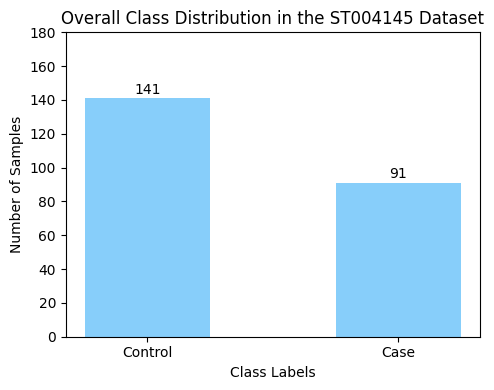

Class distribution:
Control: 141
Case: 91


In [6]:
# =========================
# Figure: Class Distribution of ST004145 Dataset
# Revised version
# =========================
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "ST004145_MERGED_log10_clean.csv"

hormone_columns = [
    "11-Dehydrocorticosterone_POS",
    "11-deoxycortisol_POS",
    "11-ketotestosterone_POS",
    "17a-OH-progesterone_POS",
    "Androstenedione_POS",
    "Corticosterone_POS",
    "Cortisol_POS",
    "Cortisone_POS",
    "Estradiol_POS",
    "Pregnenolone_POS",
    "Testosterone_POS",
    "DHEA-sulfate_NEG",
]

df = pd.read_csv(DATA_PATH)

missing = [c for c in hormone_columns if c not in df.columns]
if missing:
    raise ValueError(f"Missing hormone columns in CSV: {missing}")

if "Factor_Group" not in df.columns:
    raise ValueError("Missing 'Factor_Group' column in CSV.")

fg = df["Factor_Group"]

if fg.dtype == object:
    fg_norm = fg.astype(str).str.strip().str.lower()
    y = fg_norm.map({
        "control": 0,
        "case": 1,
        "treated": 1
    })
else:
    y = fg.copy()

if y.isna().any():
    raise ValueError("Some labels in 'Factor_Group' could not be mapped to 0/1.")

y = y.astype(int)

class_counts = y.value_counts().sort_index()

label_map = {
    0: "Control",
    1: "Case"
}
labels = [label_map.get(i, str(i)) for i in class_counts.index]
counts = class_counts.values

plt.figure(figsize=(5, 4))
bars = plt.bar(labels, counts, width=0.5, color="lightskyblue")

plt.title("Overall Class Distribution in the ST004145 Dataset")
plt.xlabel("Class Labels")
plt.ylabel("Number of Samples")
plt.ylim(0, 180)

for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(count),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

print("Class distribution:")
for lbl, cnt in zip(labels, counts):
    print(f"{lbl}: {cnt}")

In [12]:
# =========================
# Cell 5 - Load best tuning config and prepare paths
# =========================

import os
import glob
import json
import numpy as np
import pandas as pd

OOF_DIR = "oof_outputs"
os.makedirs(OOF_DIR, exist_ok=True)

BEST_TUNING_CSV_CANDIDATES = [
    "tuning_Hybrid_concat_LR_Curriculum_GAN_ALL.csv",
    "tuning_Hybrid_concat_LR_Curriculum_GAN.csv",
]

FINAL_COMPARISON_CSV = "Final_comparison_models.csv"
BASE_COMPARISON_CSV = "curriculum_comparison_selected_models.csv"

# load data
X, y = load_st004145(DATA_PATH)

# find best tuning csv
best_tuning_csv = None
for p in BEST_TUNING_CSV_CANDIDATES:
    if os.path.exists(p):
        best_tuning_csv = p
        break

if best_tuning_csv is None:
    raise FileNotFoundError(
        "Could not find tuning CSV. Expected one of: "
        + ", ".join(BEST_TUNING_CSV_CANDIDATES)
    )

tuning_best_df = pd.read_csv(best_tuning_csv)
if len(tuning_best_df) == 0:
    raise ValueError(f"{best_tuning_csv} is empty.")

best_row = tuning_best_df.sort_values("mean_auc", ascending=False).iloc[0].copy()

print("Best tuning CSV:", best_tuning_csv)
print("\nBest row:")
display(pd.DataFrame([best_row]))

Best tuning CSV: tuning_Hybrid_concat_LR_Curriculum_GAN_ALL.csv

Best row:


,cfg_key,Model,mean_auc,std_auc,auc_text,elapsed_sec,curriculum_stages,scaler_kind,lr_C,lr_solver,lr_penalty,lr_l1_ratio,lr_class_weight,gan_target_ratio,gan_epochs,gan_batch_size,gan_z_dim,gan_lr_g,gan_lr_d
79,"{""curriculum_stages"": 2, ""gan_batch_size"": 32,...",Hybrid_concat_LR_Curriculum_GAN,0.679406,0.087138,NaN,68.360438,2,robust,0.3,liblinear,l2,NaN,NaN,0.8,500,32,16,0.0002,0.0002


In [13]:
# =========================
# Cell 6 - Build best params from tuning row
# =========================

def _none_if_nan(x):
    if pd.isna(x):
        return None
    return x

best_lr_params = {
    "C": float(best_row["lr_C"]) if not pd.isna(best_row["lr_C"]) else 1.0,
    "solver": str(best_row["lr_solver"]) if not pd.isna(best_row["lr_solver"]) else "liblinear",
    "penalty": str(best_row["lr_penalty"]) if not pd.isna(best_row["lr_penalty"]) else "l2",
    "class_weight": _none_if_nan(best_row.get("lr_class_weight", None)),
    "max_iter": 5000,
}
if "lr_l1_ratio" in best_row.index and not pd.isna(best_row["lr_l1_ratio"]):
    best_lr_params["l1_ratio"] = float(best_row["lr_l1_ratio"])

best_processor_params = {
    "scaler_kind": str(best_row["scaler_kind"]) if not pd.isna(best_row["scaler_kind"]) else "robust"
}

best_gan_params = {
    "gan_target_ratio": float(best_row["gan_target_ratio"]) if not pd.isna(best_row["gan_target_ratio"]) else 1.0,
    "gan_epochs": int(best_row["gan_epochs"]) if not pd.isna(best_row["gan_epochs"]) else 250,
    "gan_batch_size": int(best_row["gan_batch_size"]) if not pd.isna(best_row["gan_batch_size"]) else 32,
    "gan_z_dim": int(best_row["gan_z_dim"]) if not pd.isna(best_row["gan_z_dim"]) else 16,
    "gan_lr_g": float(best_row["gan_lr_g"]) if not pd.isna(best_row["gan_lr_g"]) else 2e-4,
    "gan_lr_d": float(best_row["gan_lr_d"]) if not pd.isna(best_row["gan_lr_d"]) else 2e-4,
}

best_curriculum_stages = int(best_row["curriculum_stages"]) if not pd.isna(best_row["curriculum_stages"]) else 3

print("best_curriculum_stages =", best_curriculum_stages)
print("best_processor_params =", best_processor_params)
print("best_lr_params =", best_lr_params)
print("best_gan_params =", best_gan_params)

best_curriculum_stages = 2
best_processor_params = {'scaler_kind': 'robust'}
best_lr_params = {'C': 0.3, 'solver': 'liblinear', 'penalty': 'l2', 'class_weight': None, 'max_iter': 5000}
best_gan_params = {'gan_target_ratio': 0.8, 'gan_epochs': 500, 'gan_batch_size': 32, 'gan_z_dim': 16, 'gan_lr_g': 0.0002, 'gan_lr_d': 0.0002}


In [23]:
# =========================
# Cell A - Check whether winning model OOF files already exist
# =========================

import os
import glob
import pandas as pd

OOF_DIR = "oof_outputs"
winning_model = "Hybrid_concat_LR_Curriculum_GAN"

expected_files = [
    os.path.join(OOF_DIR, f"{winning_model}_y_true.npy"),
    os.path.join(OOF_DIR, f"{winning_model}_y_prob.npy"),
    os.path.join(OOF_DIR, f"{winning_model}_y_pred.npy"),
    os.path.join(OOF_DIR, f"{winning_model}_metrics.csv"),
]

check_rows = []
for f in expected_files:
    check_rows.append({
        "file": f,
        "exists": os.path.exists(f)
    })

check_df = pd.DataFrame(check_rows)
display(check_df)

print("\nAll files currently in oof_outputs:")
display(pd.DataFrame({"file": sorted(glob.glob(os.path.join(OOF_DIR, "*")))}))

,file,exists
0,oof_outputs/Hybrid_concat_LR_Curriculum_GAN_y_...,True
1,oof_outputs/Hybrid_concat_LR_Curriculum_GAN_y_...,True
2,oof_outputs/Hybrid_concat_LR_Curriculum_GAN_y_...,True
3,oof_outputs/Hybrid_concat_LR_Curriculum_GAN_me...,True



All files currently in oof_outputs:


,file
0,oof_outputs/Baseline_LR_Standard_metrics.csv
1,oof_outputs/Baseline_LR_Standard_oof_predictio...
2,oof_outputs/Baseline_LR_Standard_y_pred.npy
3,oof_outputs/Baseline_LR_Standard_y_prob.npy
4,oof_outputs/Baseline_LR_Standard_y_true.npy
5,oof_outputs/Baseline_LightGBM_Standard_metrics...
6,oof_outputs/Baseline_LightGBM_Standard_oof_pre...
7,oof_outputs/Baseline_LightGBM_Standard_y_pred.npy
8,oof_outputs/Baseline_LightGBM_Standard_y_prob.npy
9,oof_outputs/Baseline_LightGBM_Standard_y_true.npy


In [28]:
# =========================
# Cell - FINAL overwrite of Final_comparison_models.csv (safe + consistent)
# =========================

import os
import shutil
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

final_csv_path = "Final_comparison_models.csv"
backup_path = f"Final_comparison_models_backup_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
oof_dir = "oof_outputs"

# -------------------------
# 0) Backup original file
# -------------------------
if os.path.exists(final_csv_path):
    shutil.copy(final_csv_path, backup_path)
    print(f"Backup created: {backup_path}")
else:
    raise FileNotFoundError(f"{final_csv_path} not found")

# -------------------------
# 1) Load current table
# -------------------------
df = pd.read_csv(final_csv_path).copy()
df.columns = [str(c).strip() for c in df.columns]

df["mean_auc"] = pd.to_numeric(df["mean_auc"], errors="coerce")
df["std_auc"] = pd.to_numeric(df["std_auc"], errors="coerce")

# -------------------------
# 2) Inject TRUE winning result from tuning CSV
# -------------------------
tuning_file = "tuning_Hybrid_concat_LR_Curriculum_GAN_ALL.csv"
if not os.path.exists(tuning_file):
    raise FileNotFoundError("tuning CSV not found")

tuning_df = pd.read_csv(tuning_file)
tuning_df = tuning_df[tuning_df["Model"] == "Hybrid_concat_LR_Curriculum_GAN"].copy()
tuning_df["mean_auc"] = pd.to_numeric(tuning_df["mean_auc"], errors="coerce")
tuning_df["std_auc"] = pd.to_numeric(tuning_df["std_auc"], errors="coerce")

best_row = tuning_df.sort_values("mean_auc", ascending=False).iloc[0]

true_mean = float(best_row["mean_auc"])
true_std = float(best_row["std_auc"])

print("\nTRUE BEST (from tuning):")
print(f"mean_auc = {true_mean:.6f}")
print(f"std_auc  = {true_std:.6f}")

mask = df["Model"] == "Hybrid_concat_LR_Curriculum_GAN"
df.loc[mask, "mean_auc"] = true_mean
df.loc[mask, "std_auc"] = true_std

# -------------------------
# 3) Rebuild AUC-ROC column
# -------------------------
df["AUC-ROC"] = df.apply(
    lambda r: f"{r['mean_auc']:.4f} ± {r['std_auc']:.4f}"
    if pd.notna(r["mean_auc"]) and pd.notna(r["std_auc"])
    else np.nan,
    axis=1
)

# -------------------------
# 4) Recompute OOF metrics (if available)
# -------------------------
def compute_oof(model):
    yt = os.path.join(oof_dir, f"{model}_y_true.npy")
    yp = os.path.join(oof_dir, f"{model}_y_prob.npy")
    ypr = os.path.join(oof_dir, f"{model}_y_pred.npy")

    if not (os.path.exists(yt) and os.path.exists(yp) and os.path.exists(ypr)):
        return None

    y_true = np.load(yt)
    y_prob = np.load(yp)
    y_pred = np.load(ypr)

    return {
        "oof_auc": roc_auc_score(y_true, y_prob),
        "oof_accuracy": accuracy_score(y_true, y_pred),
        "oof_precision": precision_score(y_true, y_pred, zero_division=0),
        "oof_recall": recall_score(y_true, y_pred, zero_division=0),
        "oof_f1": f1_score(y_true, y_pred, zero_division=0),
    }

for col in ["oof_auc", "oof_accuracy", "oof_precision", "oof_recall", "oof_f1"]:
    if col not in df.columns:
        df[col] = np.nan

updated = []
for i, row in df.iterrows():
    m = row["Model"]
    res = compute_oof(m)
    if res:
        for k, v in res.items():
            df.loc[i, k] = v
        updated.append(m)

print("\n OOF updated for:")
for m in updated:
    print("-", m)

# -------------------------
# 5) Sort by TRUE mean_auc
# -------------------------
df = df.sort_values("mean_auc", ascending=False).reset_index(drop=True)

# -------------------------
# 6) Round for clean output
# -------------------------
for col in ["mean_auc", "std_auc", "oof_auc", "oof_accuracy", "oof_precision", "oof_recall", "oof_f1"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").round(6)

# -------------------------
# 7) OVERWRITE original
# -------------------------
df.to_csv(final_csv_path, index=False)

print("\nFINAL_comparison_models.csv has been OVERWRITTEN (corrected)")
display(df)

Backup created: Final_comparison_models_backup_20260406_031945.csv

TRUE BEST (from tuning):
mean_auc = 0.679406
std_auc  = 0.087138

 OOF updated for:
- Hybrid_concat_LR_Curriculum_GAN
- Hybrid_concat_LR_Standard_GAN
- Baseline_SVM_Standard
- Baseline_LR_Standard
- Hybrid_concat_LR_Standard_Smote
- Hybrid_concat_LR_Curriculum
- Baseline_LightGBM_Standard
- Hybrid_concat_LR_Curriculum_Smote

FINAL_comparison_models.csv has been OVERWRITTEN (corrected)


,Model,AUC-ROC,mean_auc,std_auc,oof_auc,oof_accuracy,oof_precision,oof_recall,oof_f1
0,Hybrid_concat_LR_Curriculum_GAN,0.6794 ± 0.0871,0.679406,0.087138,0.629725,0.625000,0.527027,0.428571,0.472727
1,Hybrid_concat_LR_Standard_GAN,0.6284 ± 0.1305,0.628430,0.130460,0.542982,0.581897,0.461538,0.395604,0.426036
2,Baseline_SVM_Standard,0.6138 ± 0.0573,0.613838,0.057296,0.608253,0.650862,0.647059,0.241758,0.352000
3,Baseline_LR_Standard,0.6129 ± 0.0883,0.612864,0.088265,0.604318,0.629310,0.777778,0.076923,0.140000
4,Hybrid_concat_LR_Standard_Smote,0.6059 ± 0.0676,0.605870,0.067569,0.578755,0.581897,0.466667,0.461538,0.464088
5,Hybrid_concat_LR_Curriculum,0.6001 ± 0.0941,0.600127,0.094066,0.639779,0.629310,0.526316,0.549451,0.537634
6,Baseline_LightGBM_Standard,0.5959 ± 0.0633,0.595860,0.063334,0.598395,0.646552,0.573770,0.384615,0.460526
7,Hybrid_concat_LR_Curriculum_Smote,0.5815 ± 0.0640,0.581528,0.064004,0.624347,0.625000,0.521739,0.527473,0.524590


In [29]:
# =========================
# Cell 10 - Build metrics table with OFFICIAL mean_auc + current saved OOF metrics
# =========================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

OOF_DIR = "oof_outputs"

# thesis order
preferred_model_order = [
    "Baseline_LR_Standard",
    "Baseline_SVM_Standard",
    "Baseline_LightGBM_Standard",
    "Hybrid_concat_LR_Standard_GAN",
    "Hybrid_concat_LR_Standard_Smote",
    "Hybrid_concat_LR_Curriculum",
    "Hybrid_concat_LR_Curriculum_GAN",
    "Hybrid_concat_LR_Curriculum_Smote",
]

# official final comparison
official_df = pd.read_csv("Final_comparison_models.csv").copy()
official_df.columns = [str(c).strip() for c in official_df.columns]

for c in ["mean_auc", "std_auc"]:
    if c in official_df.columns:
        official_df[c] = pd.to_numeric(official_df[c], errors="coerce")

# only keep models of interest
official_df = official_df[official_df["Model"].isin(preferred_model_order)].copy()
official_df["Model"] = pd.Categorical(
    official_df["Model"],
    categories=preferred_model_order,
    ordered=True
)
official_df = official_df.sort_values("Model").reset_index(drop=True)

# compute OOF metrics from currently saved files
rows = []
for model in official_df["Model"].astype(str):
    row = {"Model": model}

    y_true_path = os.path.join(OOF_DIR, f"{model}_y_true.npy")
    y_prob_path = os.path.join(OOF_DIR, f"{model}_y_prob.npy")
    y_pred_path = os.path.join(OOF_DIR, f"{model}_y_pred.npy")

    if os.path.exists(y_true_path) and os.path.exists(y_prob_path) and os.path.exists(y_pred_path):
        y_true = np.load(y_true_path)
        y_prob = np.load(y_prob_path)
        y_pred = np.load(y_pred_path)

        row["Accuracy"] = accuracy_score(y_true, y_pred)
        row["F1 Score"] = f1_score(y_true, y_pred, zero_division=0)
        row["Precision"] = precision_score(y_true, y_pred, zero_division=0)
        row["Recall"] = recall_score(y_true, y_pred, zero_division=0)
        row["OOF AUC"] = roc_auc_score(y_true, y_prob)
    else:
        row["Accuracy"] = np.nan
        row["F1 Score"] = np.nan
        row["Precision"] = np.nan
        row["Recall"] = np.nan
        row["OOF AUC"] = np.nan

    rows.append(row)

oof_metrics_df = pd.DataFrame(rows)

# merge official mean AUC + current OOF metrics
classification_metrics_summary_df = official_df.merge(
    oof_metrics_df,
    on="Model",
    how="left"
)

# rename official columns for clarity
classification_metrics_summary_df = classification_metrics_summary_df.rename(columns={
    "mean_auc": "Official Mean AUC",
    "std_auc": "Official Std AUC"
})

# keep columns
classification_metrics_summary_df = classification_metrics_summary_df[
    ["Model", "Accuracy", "F1 Score", "Precision", "Recall", "OOF AUC", "Official Mean AUC", "Official Std AUC"]
]

classification_metrics_summary_display_df = classification_metrics_summary_df.copy()
for col in ["Accuracy", "F1 Score", "Precision", "Recall", "OOF AUC", "Official Mean AUC", "Official Std AUC"]:
    classification_metrics_summary_display_df[col] = pd.to_numeric(
        classification_metrics_summary_display_df[col], errors="coerce"
    ).round(4)

classification_metrics_summary_display_df.to_csv(
    "classification_metrics_summary_table_corrected.csv",
    index=False
)

print("Saved: classification_metrics_summary_table_corrected.csv")
display(classification_metrics_summary_display_df)

Saved: classification_metrics_summary_table_corrected.csv


,Model,Accuracy,F1 Score,Precision,Recall,OOF AUC,Official Mean AUC,Official Std AUC
0,Baseline_LR_Standard,0.6293,0.1400,0.7778,0.0769,0.6043,0.6129,0.0883
1,Baseline_SVM_Standard,0.6509,0.3520,0.6471,0.2418,0.6083,0.6138,0.0573
2,Baseline_LightGBM_Standard,0.6466,0.4605,0.5738,0.3846,0.5984,0.5959,0.0633
3,Hybrid_concat_LR_Standard_GAN,0.5819,0.4260,0.4615,0.3956,0.5430,0.6284,0.1305
4,Hybrid_concat_LR_Standard_Smote,0.5819,0.4641,0.4667,0.4615,0.5788,0.6059,0.0676
5,Hybrid_concat_LR_Curriculum,0.6293,0.5376,0.5263,0.5495,0.6398,0.6001,0.0941
6,Hybrid_concat_LR_Curriculum_GAN,0.6250,0.4727,0.5270,0.4286,0.6297,0.6794,0.0871
7,Hybrid_concat_LR_Curriculum_Smote,0.6250,0.5246,0.5217,0.5275,0.6243,0.5815,0.0640


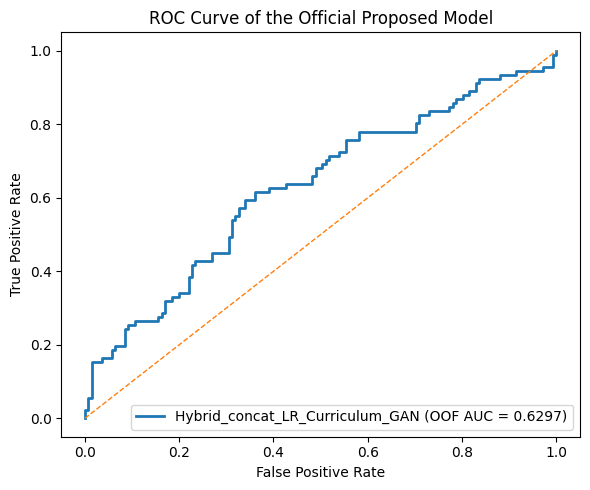

Saved: figure_proposed_model_roc_curve_oof.png
Official mean AUC (5-fold mean): 0.679406
Official std AUC  (5-fold std) : 0.087138
Saved OOF pooled AUC          : 0.629725


In [32]:
# =========================
# Cell 11 - ROC curve of the official winning model from saved OOF
# =========================

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

OOF_DIR = "oof_outputs"
winning_model = "Hybrid_concat_LR_Curriculum_GAN"

y_true = np.load(os.path.join(OOF_DIR, f"{winning_model}_y_true.npy"))
y_prob = np.load(os.path.join(OOF_DIR, f"{winning_model}_y_prob.npy"))

fpr, tpr, _ = roc_curve(y_true, y_prob)
oof_auc_val = roc_auc_score(y_true, y_prob)

# official mean AUC
official_df = pd.read_csv("Final_comparison_models.csv")
official_row = official_df[official_df["Model"] == winning_model].iloc[0]
official_mean_auc = float(official_row["mean_auc"])
official_std_auc = float(official_row["std_auc"])

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2,
         label=f"{winning_model} (OOF AUC = {oof_auc_val:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of the Official Proposed Model")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figure_proposed_model_roc_curve_oof.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figure_proposed_model_roc_curve_oof.png")
print(f"Official mean AUC (5-fold mean): {official_mean_auc:.6f}")
print(f"Official std AUC  (5-fold std) : {official_std_auc:.6f}")
print(f"Saved OOF pooled AUC          : {oof_auc_val:.6f}")

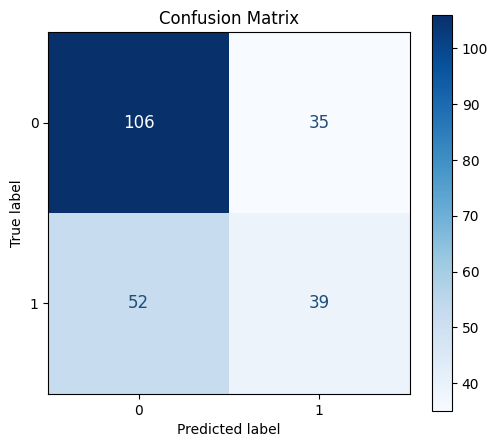

Saved
Confusion matrix:
 [[106  35]
 [ 52  39]]


In [35]:
# =========================
# Cell 12 - Styled confusion matrix of the official winning model
# =========================

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

OOF_DIR = "oof_outputs"
winning_model = "Hybrid_concat_LR_Curriculum_GAN"

y_true = np.load(os.path.join(OOF_DIR, f"{winning_model}_y_true.npy"))
y_pred = np.load(os.path.join(OOF_DIR, f"{winning_model}_y_pred.npy"))

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5.2, 4.6))

im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
cbar = plt.colorbar(im, ax=ax)

# axis labels and title
ax.set(
    xticks=np.arange(cm.shape[1]),
    yticks=np.arange(cm.shape[0]),
    xticklabels=[0, 1],
    yticklabels=[0, 1],
    xlabel="Predicted label",
    ylabel="True label",
    title="Confusion Matrix"
)

# annotate cells
thresh = (cm.max() + cm.min()) / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, format(cm[i, j], "d"),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "#1f4e79",
            fontsize=12
        )

fig.tight_layout()
plt.savefig("figure_proposed_model_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved")
print("Confusion matrix:\n", cm)

In [40]:
# =========================
# Cell 16 - Merge official final comparison with corrected metrics (selected columns only)
# =========================

official_final_df = pd.read_csv("Final_comparison_models.csv").copy()
official_final_df.columns = [str(c).strip() for c in official_final_df.columns]

corrected_metrics_df = pd.read_csv("classification_metrics_summary_table_corrected.csv").copy()
corrected_metrics_df.columns = [str(c).strip() for c in corrected_metrics_df.columns]

merged_final_df = official_final_df.merge(
    corrected_metrics_df,
    on="Model",
    how="left"
)

# keep only requested columns
keep_cols = [
    "Model",
    "AUC-ROC",
    "mean_auc",
    "std_auc",
    "Accuracy",
    "F1 Score",
    "Precision",
    "Recall",
]

merged_final_df = merged_final_df[keep_cols].copy()

# optional ordering
preferred_model_order = [
    "Baseline_LR_Standard",
    "Baseline_SVM_Standard",
    "Baseline_LightGBM_Standard",
    "Hybrid_concat_LR_Standard_GAN",
    "Hybrid_concat_LR_Standard_Smote",
    "Hybrid_concat_LR_Curriculum",
    "Hybrid_concat_LR_Curriculum_GAN",
    "Hybrid_concat_LR_Curriculum_Smote",
]

merged_final_df["Model"] = pd.Categorical(
    merged_final_df["Model"],
    categories=preferred_model_order,
    ordered=True
)

# if you want ranking order by mean_auc, use this:
merged_final_df = merged_final_df.sort_values("mean_auc", ascending=False).reset_index(drop=True)

# round numeric columns
for col in ["mean_auc", "std_auc", "Accuracy", "F1 Score", "Precision", "Recall"]:
    merged_final_df[col] = pd.to_numeric(merged_final_df[col], errors="coerce").round(4)

merged_final_df.to_csv("Final_merged_table_selected_columns.csv", index=False)

print("Saved: Final_merged_table_selected_columns.csv")
display(merged_final_df)

Saved: Final_merged_table_selected_columns.csv


,Model,AUC-ROC,mean_auc,std_auc,Accuracy,F1 Score,Precision,Recall
0,Hybrid_concat_LR_Curriculum_GAN,0.6794 ± 0.0871,0.6794,0.0871,0.6250,0.4727,0.5270,0.4286
1,Hybrid_concat_LR_Standard_GAN,0.6284 ± 0.1305,0.6284,0.1305,0.5819,0.4260,0.4615,0.3956
2,Baseline_SVM_Standard,0.6138 ± 0.0573,0.6138,0.0573,0.6509,0.3520,0.6471,0.2418
3,Baseline_LR_Standard,0.6129 ± 0.0883,0.6129,0.0883,0.6293,0.1400,0.7778,0.0769
4,Hybrid_concat_LR_Standard_Smote,0.6059 ± 0.0676,0.6059,0.0676,0.5819,0.4641,0.4667,0.4615
5,Hybrid_concat_LR_Curriculum,0.6001 ± 0.0941,0.6001,0.0941,0.6293,0.5376,0.5263,0.5495
6,Baseline_LightGBM_Standard,0.5959 ± 0.0633,0.5959,0.0633,0.6466,0.4605,0.5738,0.3846
7,Hybrid_concat_LR_Curriculum_Smote,0.5815 ± 0.0640,0.5815,0.0640,0.6250,0.5246,0.5217,0.5275


In [47]:
# =========================
# Cell 17 - Build thesis-ready ablation summary and delta tables
# =========================

import pandas as pd
import numpy as np

# Load the merged model comparison table generated previously
df = pd.read_csv("Final_merged_table_selected_columns.csv").copy()

# Clean column names
df.columns = [str(c).strip() for c in df.columns]

# -------------------------
# 1. Keep only the selected models for the ablation study
# -------------------------
selected_models = [
    "Baseline_SVM_Standard",
    "Hybrid_concat_LR_Standard_GAN",
    "Hybrid_concat_LR_Curriculum",
    "Hybrid_concat_LR_Curriculum_GAN",
]

df = df[df["Model"].isin(selected_models)].copy()

# -------------------------
# 2. Add component indicator columns
# -------------------------
def has_curriculum(model_name):
    return "✓" if "Curriculum" in str(model_name) else "✗"

def has_gan(model_name):
    return "✓" if "_GAN" in str(model_name) else "✗"

df["Curriculum"] = df["Model"].apply(has_curriculum)
df["GAN"] = df["Model"].apply(has_gan)

# -------------------------
# 3. Keep only the required columns for the ablation summary table
# -------------------------
summary_df = df[
    [
        "Model",
        "Curriculum",
        "GAN",
        "AUC-ROC",
        "mean_auc",
        "std_auc",
        "Accuracy",
        "F1 Score",
        "Precision",
        "Recall",
    ]
].copy()

# -------------------------
# 4. Convert numeric columns and sort by mean AUC in descending order
# -------------------------
numeric_cols = ["mean_auc", "std_auc", "Accuracy", "F1 Score", "Precision", "Recall"]

for col in numeric_cols:
    summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce")

summary_df = summary_df.sort_values("mean_auc", ascending=False).reset_index(drop=True)

# -------------------------
# 5. Insert a numbering column starting from 1
# -------------------------
summary_df.insert(0, "No.", range(1, len(summary_df) + 1))

# -------------------------
# 6. Round numeric columns for cleaner presentation
# -------------------------
for col in numeric_cols:
    summary_df[col] = summary_df[col].round(4)

# -------------------------
# 7. Save and display the formatted ablation summary table
# -------------------------
summary_df.to_csv("chapter5_ablation_table_final_selected.csv", index=False)

print("Saved: chapter5_ablation_table_final_selected.csv")
display(summary_df)

# =========================================================
# 8. Build the refined ablation delta table (mean AUC only)
# =========================================================

def get_row(table, model_name):
    row = table[table["Model"] == model_name]
    if len(row) == 0:
        return None
    return row.iloc[0]

comparisons = [
    (
        "Effect of Curriculum under GAN",
        "Hybrid_concat_LR_Standard_GAN",
        "Hybrid_concat_LR_Curriculum_GAN",
    ),
    (
        "Effect of GAN under Curriculum",
        "Hybrid_concat_LR_Curriculum",
        "Hybrid_concat_LR_Curriculum_GAN",
    ),
    (
        "Effect of the full transformer-hybrid framework over baseline",
        "Baseline_SVM_Standard",
        "Hybrid_concat_LR_Curriculum_GAN",
    ),
]

delta_rows = []

for comparison_name, base_model, compared_model in comparisons:
    base_row = get_row(summary_df, base_model)
    compared_row = get_row(summary_df, compared_model)

    if base_row is None or compared_row is None:
        continue

    base_auc = pd.to_numeric(base_row["mean_auc"], errors="coerce")
    compared_auc = pd.to_numeric(compared_row["mean_auc"], errors="coerce")
    delta_auc = round(compared_auc - base_auc, 4)

    delta_rows.append({
        "Comparison": comparison_name,
        "Base Model": base_model,
        "Compared Model": compared_model,
        "From mean_auc": round(base_auc, 4),
        "→": "→",
        "To mean_auc": round(compared_auc, 4),
        "Δmean_auc": delta_auc,
    })

ablation_delta_df = pd.DataFrame(delta_rows)

# Save and display the refined delta table
ablation_delta_df.to_csv("chapter5_ablation_delta_mean_auc.csv", index=False)

print("Saved: chapter5_ablation_delta_mean_auc.csv")
display(ablation_delta_df)

Saved: chapter5_ablation_table_final_selected.csv


,No.,Model,Curriculum,GAN,AUC-ROC,mean_auc,std_auc,Accuracy,F1 Score,Precision,Recall
0,1,Hybrid_concat_LR_Curriculum_GAN,✓,✓,0.6794 ± 0.0871,0.6794,0.0871,0.6250,0.4727,0.5270,0.4286
1,2,Hybrid_concat_LR_Standard_GAN,✗,✓,0.6284 ± 0.1305,0.6284,0.1305,0.5819,0.4260,0.4615,0.3956
2,3,Baseline_SVM_Standard,✗,✗,0.6138 ± 0.0573,0.6138,0.0573,0.6509,0.3520,0.6471,0.2418
3,4,Hybrid_concat_LR_Curriculum,✓,✗,0.6001 ± 0.0941,0.6001,0.0941,0.6293,0.5376,0.5263,0.5495


Saved: chapter5_ablation_delta_mean_auc.csv


,Comparison,Base Model,Compared Model,From mean_auc,→,To mean_auc,Δmean_auc
0,Effect of Curriculum under GAN,Hybrid_concat_LR_Standard_GAN,Hybrid_concat_LR_Curriculum_GAN,0.6284,→,0.6794,0.0510
1,Effect of GAN under Curriculum,Hybrid_concat_LR_Curriculum,Hybrid_concat_LR_Curriculum_GAN,0.6001,→,0.6794,0.0793
2,Effect of the full transformer-hybrid framewor...,Baseline_SVM_Standard,Hybrid_concat_LR_Curriculum_GAN,0.6138,→,0.6794,0.0656


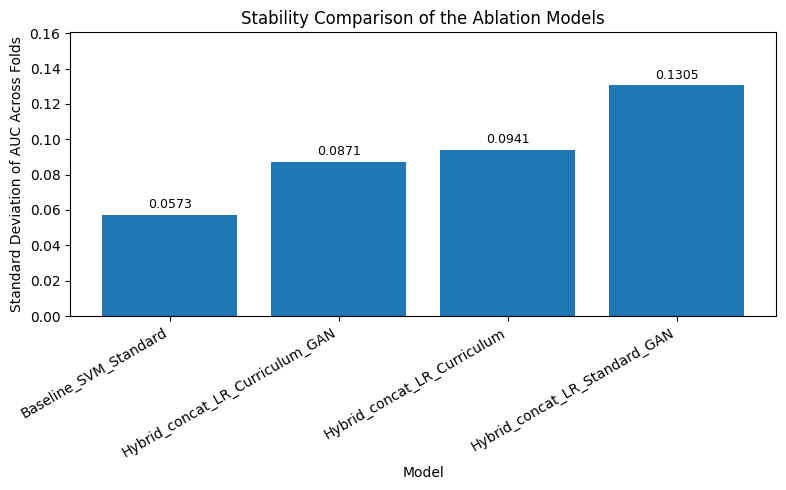

Saved:stability_comparison_selected_models.png


In [51]:
# =========================
# Cell 18 Stability comparison (selected models only)
# =========================

import pandas as pd
import matplotlib.pyplot as plt

selected_models = [
    "Baseline_SVM_Standard",
    "Hybrid_concat_LR_Standard_GAN",
    "Hybrid_concat_LR_Curriculum",
    "Hybrid_concat_LR_Curriculum_GAN",
]

chapter5_stability_df = pd.read_csv("Final_comparison_models.csv").copy()
chapter5_stability_df.columns = [str(c).strip() for c in chapter5_stability_df.columns]

chapter5_stability_df = chapter5_stability_df[
    chapter5_stability_df["Model"].isin(selected_models)
][["Model", "std_auc"]].copy()

chapter5_stability_df["std_auc"] = pd.to_numeric(chapter5_stability_df["std_auc"], errors="coerce")
chapter5_stability_df = chapter5_stability_df.dropna(subset=["std_auc"])
chapter5_stability_df = chapter5_stability_df.sort_values("std_auc", ascending=True).reset_index(drop=True)

plt.figure(figsize=(8, 5))
bars = plt.bar(chapter5_stability_df["Model"], chapter5_stability_df["std_auc"])

for bar, value in zip(bars, chapter5_stability_df["std_auc"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xticks(rotation=30, ha="right")
plt.ylabel("Standard Deviation of AUC Across Folds")
plt.xlabel("Model")
plt.title("Stability Comparison of the Ablation Models")
plt.ylim(0, chapter5_stability_df["std_auc"].max() + 0.03)

plt.tight_layout()
plt.savefig("stability_comparison_selected_models.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:stability_comparison_selected_models.png")

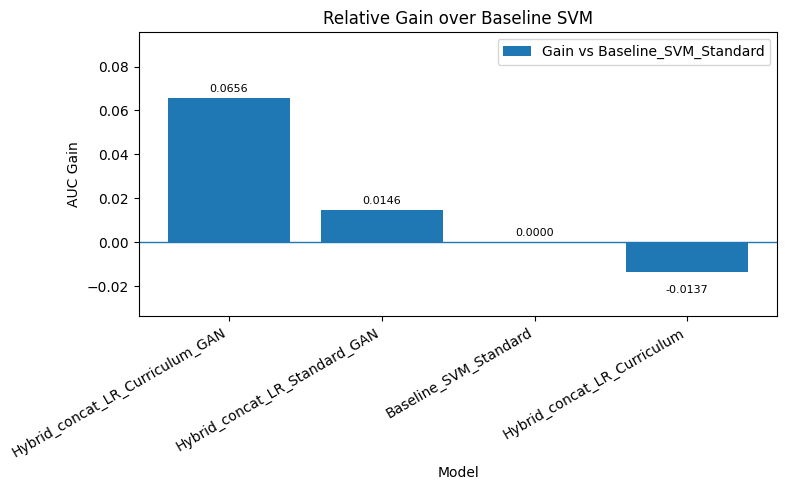

Saved:relative_gain_vs_svm_selected_models.png
Saved:table_relative_gain_vs_svm_selected_models.csv


In [57]:
# =========================
# Cell 19 - Relative gain over Baseline_SVM_Standard (selected models only)
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

selected_models = [
    "Baseline_SVM_Standard",
    "Hybrid_concat_LR_Standard_GAN",
    "Hybrid_concat_LR_Curriculum",
    "Hybrid_concat_LR_Curriculum_GAN",
]

final_df = pd.read_csv("Final_comparison_models.csv").copy()
final_df.columns = [str(c).strip() for c in final_df.columns]

final_df["mean_auc"] = pd.to_numeric(final_df["mean_auc"], errors="coerce")
final_df["std_auc"] = pd.to_numeric(final_df["std_auc"], errors="coerce")

final_df = final_df[
    final_df["Model"].isin(selected_models)
].dropna(subset=["mean_auc"]).reset_index(drop=True)

svm_base = final_df.loc[
    final_df["Model"] == "Baseline_SVM_Standard", "mean_auc"
].iloc[0]

gain_df = final_df.copy()
gain_df["gain_vs_SVM"] = gain_df["mean_auc"] - svm_base

gain_df = gain_df.sort_values("gain_vs_SVM", ascending=False).reset_index(drop=True)

x = np.arange(len(gain_df))

plt.figure(figsize=(8, 5))
bars = plt.bar(x, gain_df["gain_vs_SVM"], label="Gain vs Baseline_SVM_Standard")

plt.axhline(0, linewidth=1)

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + (0.002 if h >= 0 else -0.006),
        f"{h:.4f}",
        ha="center",
        va="bottom" if h >= 0 else "top",
        fontsize=8
    )

plt.xticks(x, gain_df["Model"], rotation=30, ha="right")
plt.ylabel("AUC Gain")
plt.xlabel("Model")
plt.title("Relative Gain over Baseline SVM")

ymin = gain_df["gain_vs_SVM"].min()
ymax = gain_df["gain_vs_SVM"].max()
plt.ylim(ymin - 0.02, ymax + 0.03)

plt.legend()
plt.tight_layout()
plt.savefig("relative_gain_vs_svm.png", dpi=300, bbox_inches="tight")
plt.show()

gain_df[["Model", "mean_auc", "std_auc", "gain_vs_SVM"]].to_csv(
    "chapter5_table_relative_gain_vs_svm.csv", index=False
)

print("Saved:relative_gain_vs_svm_selected_models.png")
print("Saved:table_relative_gain_vs_svm_selected_models.csv")